# Parte A: Aprendizaje Supervisado

## ¿Qué información presenta el dataset?, describir las principales características del dataset.

El dataset contiene descripciones de muestras hipotéticas de 23 especies de hongos con laminillas pertenecientes a la familia Agaricus y Lepiota, tomadas del Audubon Society Field Guide to North American Mushrooms (1981).

Cada muestra está clasificada como comestible (e) o venenosa (p) (esta última categoría incluye también hongos de edibilidad desconocida o no recomendada).

El dataset describe detalladamente distintas características morfológicas de hongos, registradas mediante 22 variables categóricas, cada una representada por una letra. A continuación se presentan las variables junto con sus categorías y sus códigos:

cap-shape (forma del sombrero): b=bell, c=conical, x=convex, f=flat, k=knobbed, s=sunken.

cap-surface (superficie del sombrero): f=fibrous, g=grooves, y=scaly, s=smooth.

cap-color (color del sombrero): n=brown, b=buff, c=cinnamon, g=gray, r=green, p=pink, u=purple, e=red, w=white, y=yellow.

bruises (moretones): t=bruises, f=no bruises.

odor (olor): a=almond, l=anise, c=creosote, y=fishy, f=foul, m=musty, n=none, p=pungent, s=spicy.

gill-attachment (unión de las láminas): a=attached, d=descending, f=free, n=notched.

gill-spacing (espaciado): c=close, w=crowded, d=distant.

gill-size (tamaño): b=broad, n=narrow.

gill-color (color): k=black, n=brown, b=buff, h=chocolate, g=gray, r=green, o=orange, p=pink, u=purple, e=red, w=white, y=yellow.

stalk-shape (forma del tallo): e=enlarging, t=tapering.

stalk-root (raíz del tallo): b=bulbous, c=club, u=cup, e=equal, z=rhizomorphs, r=rooted, ?=missing.

stalk-surface-above-ring (superficie del tallo arriba del anillo): f=fibrous, y=scaly, k=silky, s=smooth.

stalk-surface-below-ring (superficie del tallo debajo del anillo): f=fibrous, y=scaly, k=silky, s=smooth.

stalk-color-above-ring (color del tallo arriba): n=brown, b=buff, c=cinnamon, g=gray, o=orange, p=pink, e=red, w=white, y=yellow.

stalk-color-below-ring (color del tallo abajo): n=brown, b=buff, c=cinnamon, g=gray, o=orange, p=pink, e=red, w=white, y=yellow.

veil-type (tipo de velo): p=partial, u=universal.

veil-color (color del velo): n=brown, o=orange, w=white, y=yellow.

ring-number (número de anillos): n=none, o=one, t=two.

ring-type (tipo de anillo): c=cobwebby, e=evanescent, f=flaring, l=large, n=none, p=pendant, s=sheathing, z=zone.

spore-print-color (color de la impresión de esporas): k=black, n=brown, b=buff, h=chocolate, r=green, o=orange, u=purple, w=white, y=yellow.

population (población): a=abundant, c=clustered, n=numerous, s=scattered, v=several, y=solitary.

habitat (hábitat): g=grasses, l=leaves, m=meadows, p=paths, u=urban, w=waste, d=woods.

Estas variables permiten describir completamente la apariencia, estructura y entorno de cada muestra de hongo.

## Realice un análisis gráfico y estadístico que permita ver la distribución y ver algunas correlaciones.

In [24]:
#descargar pandas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency


In [25]:
#carcar el dataset
df_mushrooms = pd.read_csv('mushrooms.csv')

In [26]:
df_mushrooms.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [27]:
df_mushrooms.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

In [28]:
#ver is hay volumnas vadcias o celdas nulas
df_mushrooms.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [29]:
df_mushrooms_encoded = df_mushrooms.apply(lambda col: pd.factorize(col)[0])

In [30]:
df_mushrooms_encoded.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,1,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,1,1
2,1,1,0,2,0,2,0,0,1,1,...,0,0,0,0,0,0,0,1,1,2
3,0,0,1,2,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,3,1,3,0,1,1,0,...,0,0,0,0,0,0,1,1,2,1


### Correlación

todas las variables son categóricas no ordinales, entonces no podemos usar un diagrama de correlación convencional

In [33]:
#drop veil-type
df_mushrooms = df_mushrooms.drop('veil-type', axis=1)

In [34]:
# -------------------------------
# Función para calcular Cramer's V
# -------------------------------
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

In [35]:
cols = df_mushrooms.columns
cramers_matrix = pd.DataFrame(np.zeros((len(cols), len(cols))), 
                              columns=cols, index=cols)

for c1 in cols:
    for c2 in cols:
        cramers_matrix.loc[c1, c2] = cramers_v(df_mushrooms[c1], df_mushrooms[c2])

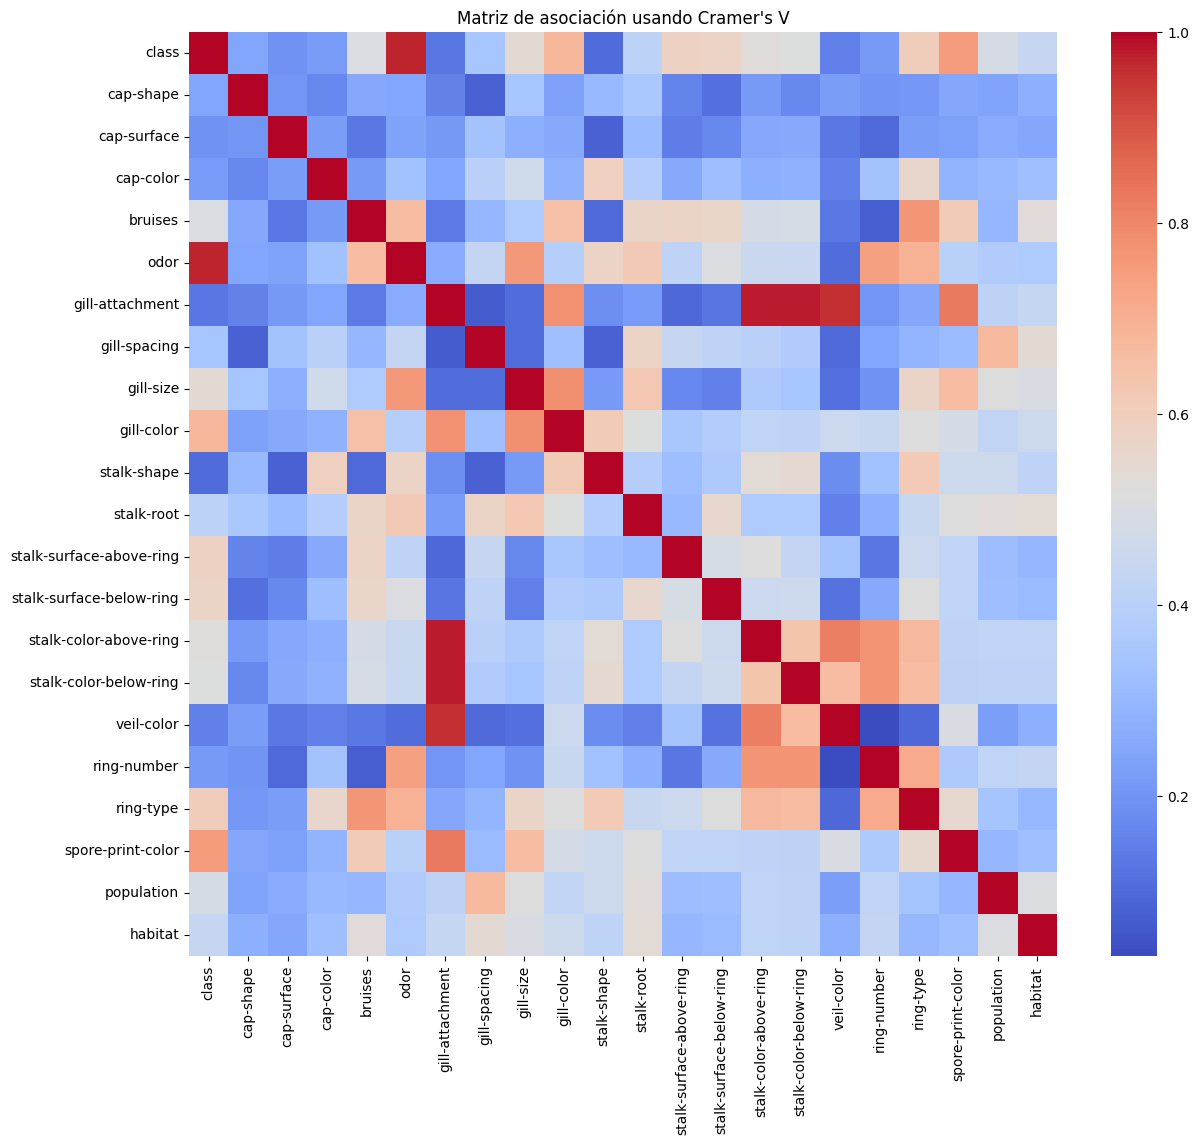

In [36]:
# -------------------------------
# Graficar heatmap
# -------------------------------
plt.figure(figsize=(14, 12))
sns.heatmap(cramers_matrix, cmap="coolwarm", annot=False)
plt.title("Matriz de asociación usando Cramer's V")
plt.show()

Cramer's V mide fuerza de asociación entre dos variables categóricas.
Los valores van de:
0.0 → sin asociación

0.1 – 0.3 → asociación débil

0.3 – 0.6 → asociación moderada

0.6 → asociación fuerte

1.0 → asociación perfecta (solo diagonal; misma variable)

odor (olor): suele ser rojo intenso 

El olor es el atributo más determinante para saber si un hongo es venenoso o comestible.

spore-print-color (color de impresión de esporas):

ayuda muchísimo a diferenciar clases.

# Graficas

In [45]:
# Asegurar estilo bonito
sns.set(style="whitegrid")

def plot_category_distribution(df, column):
    """
    Grafica cómo se distribuyen las categorías de una variable
    entre las clases edible y poisonous.
    """
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=column, hue="class")
    plt.title(f"Distribución de '{column}' por clase (edible vs poisonous)")
    plt.xlabel(column)
    plt.ylabel("Frecuencia")
    plt.legend(title="class", labels=["poisonous", "edible"])
    plt.tight_layout()
    plt.show()


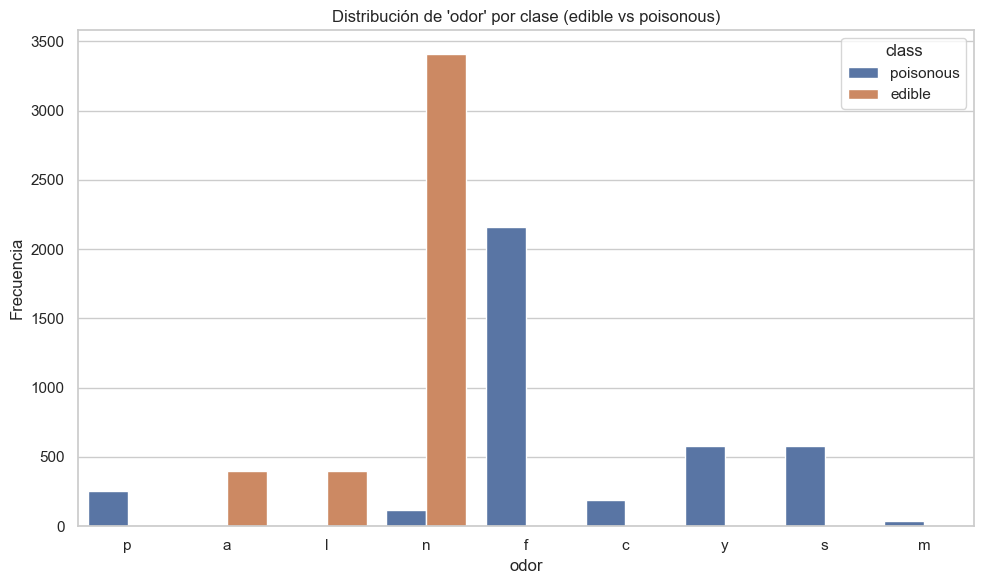

In [46]:
# Ejemplo: graficar para 'odor'
plot_category_distribution(df_mushrooms, "odor")

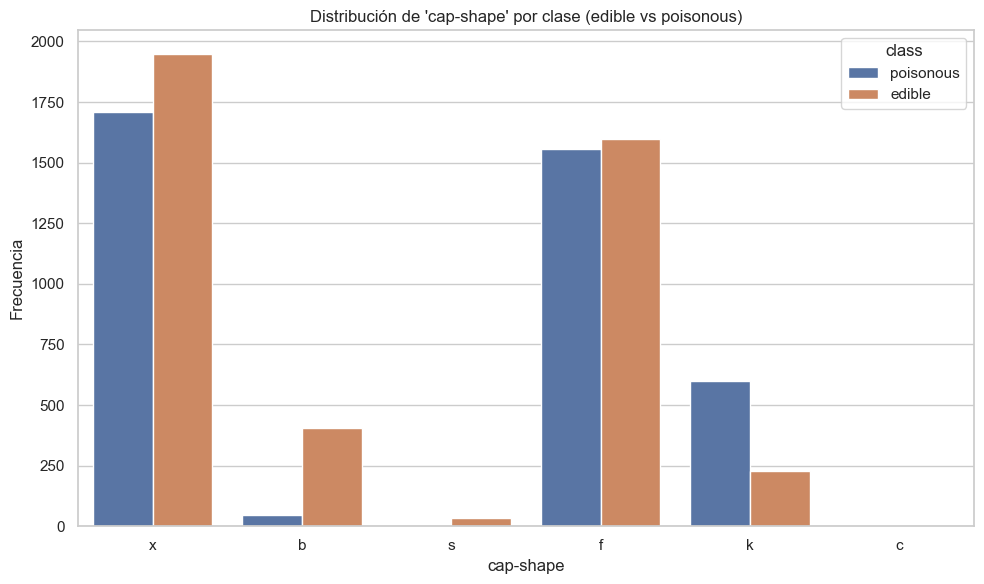

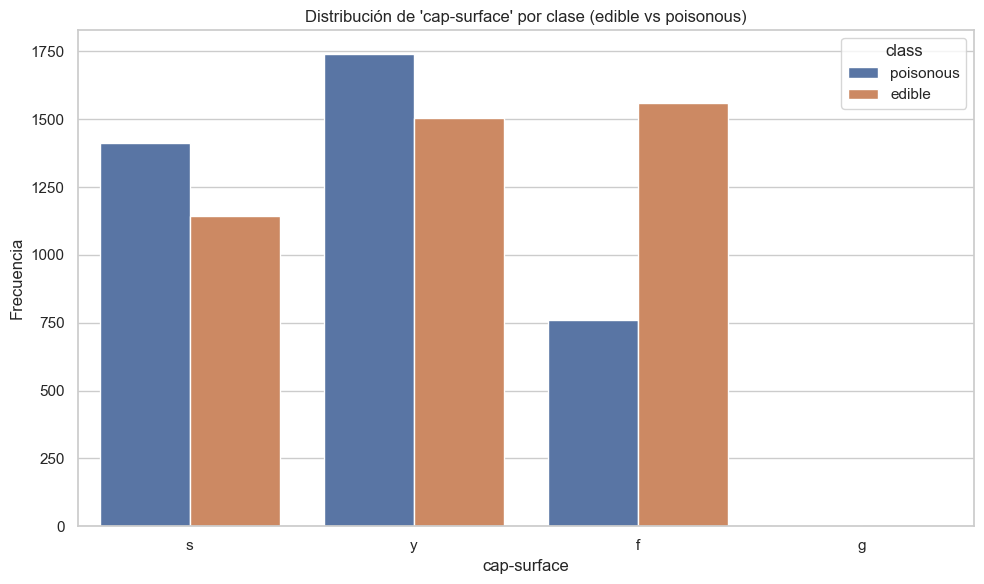

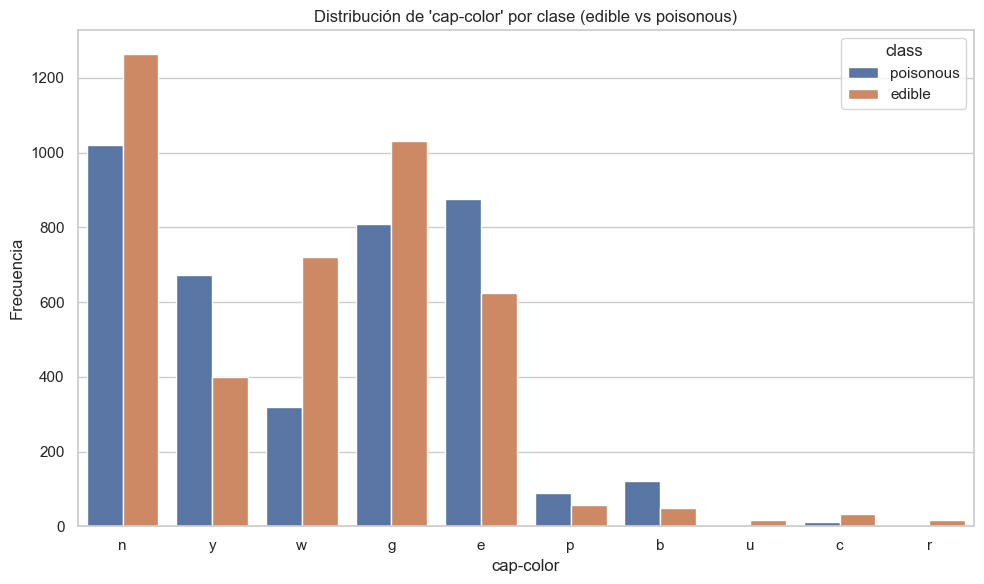

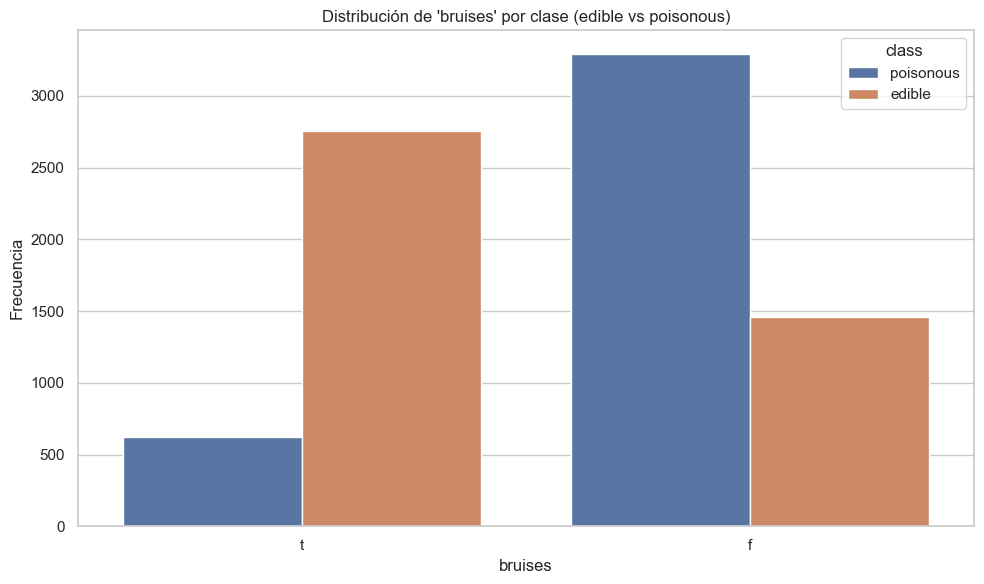

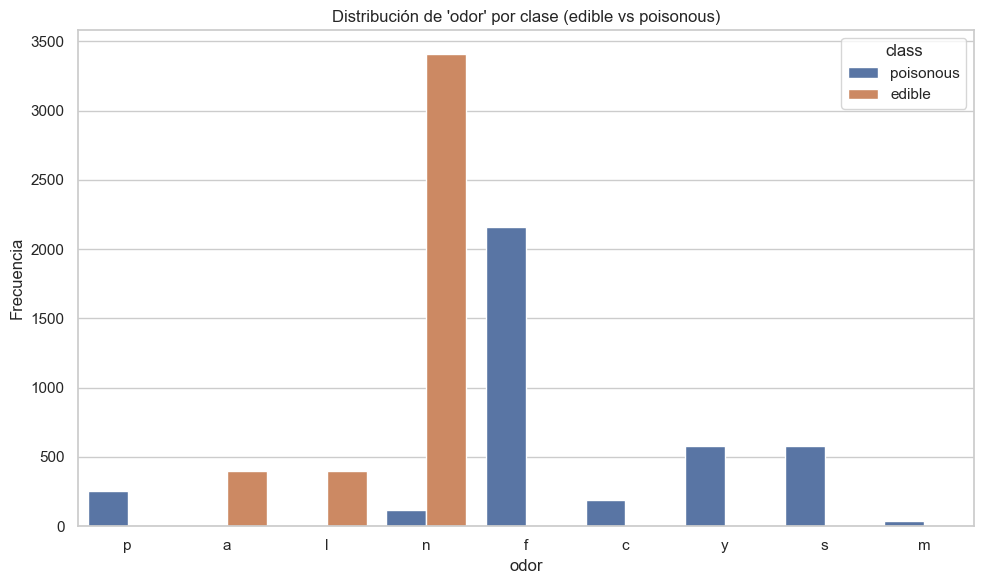

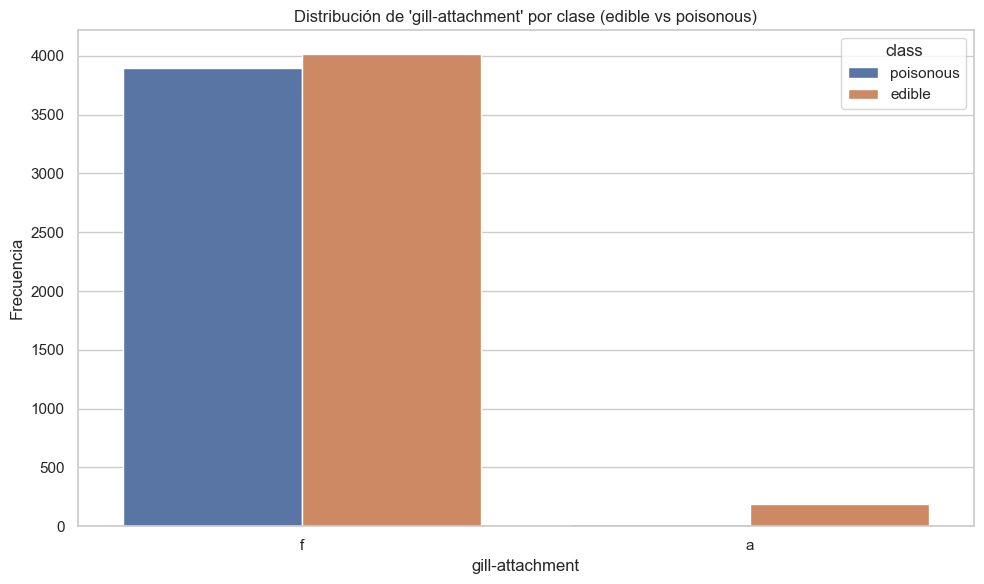

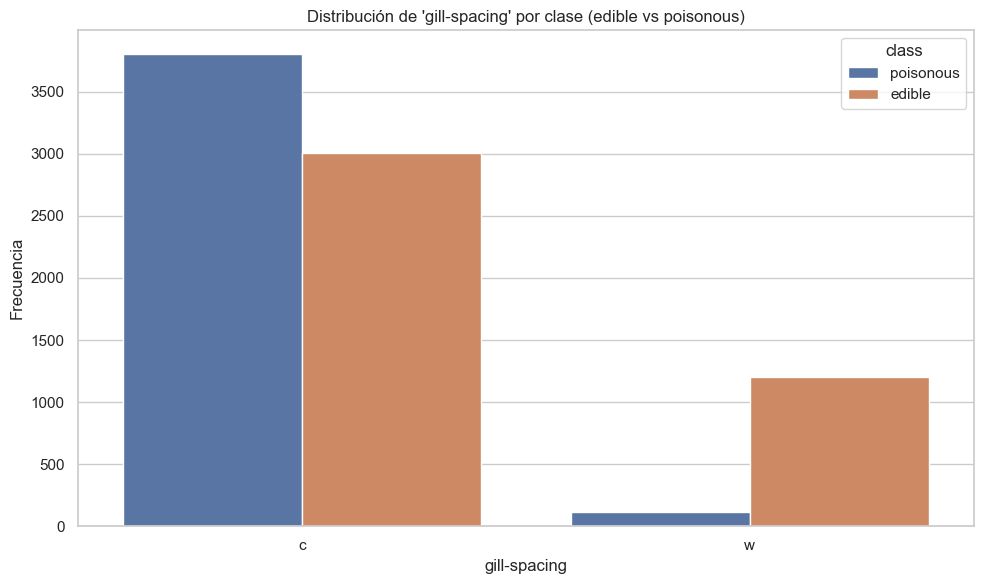

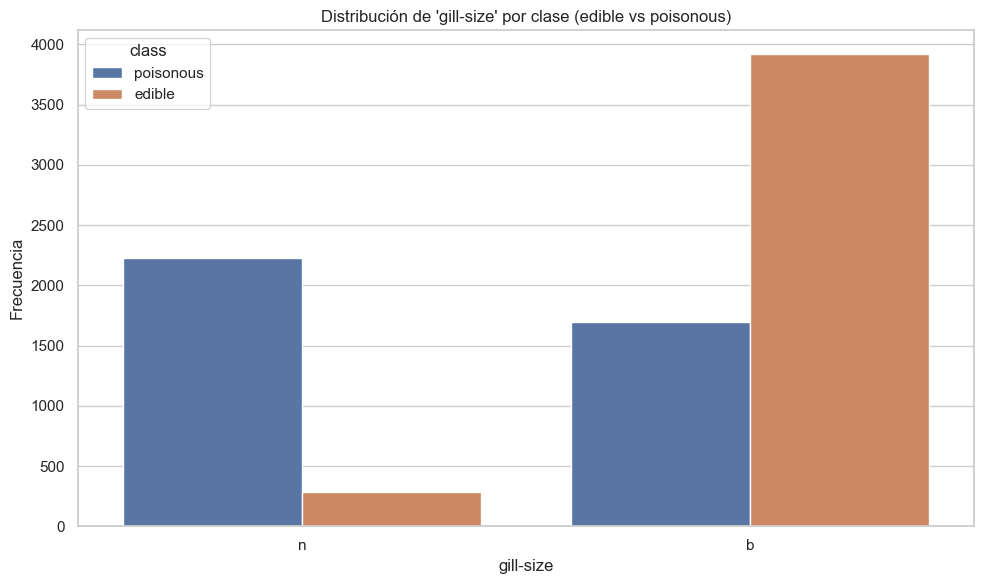

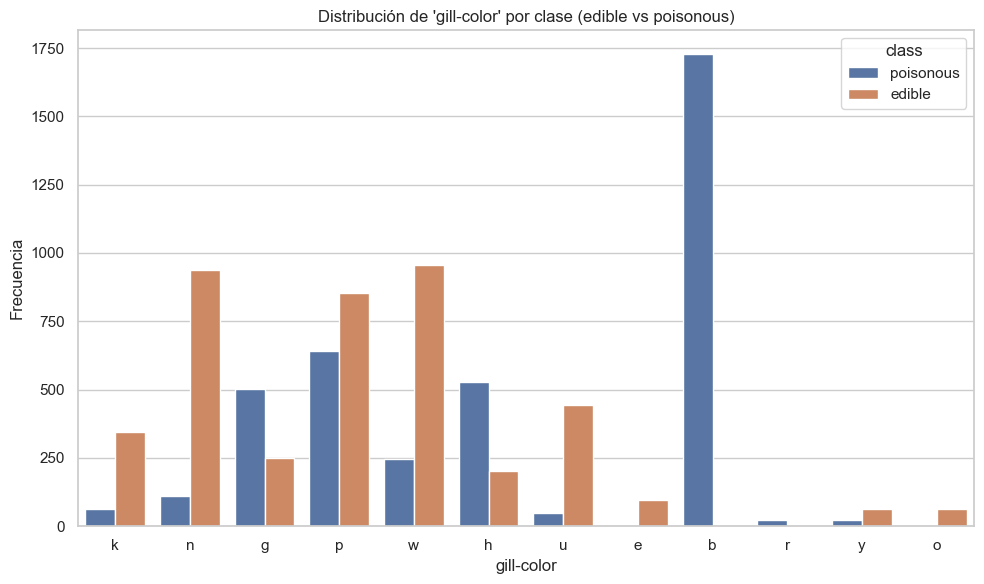

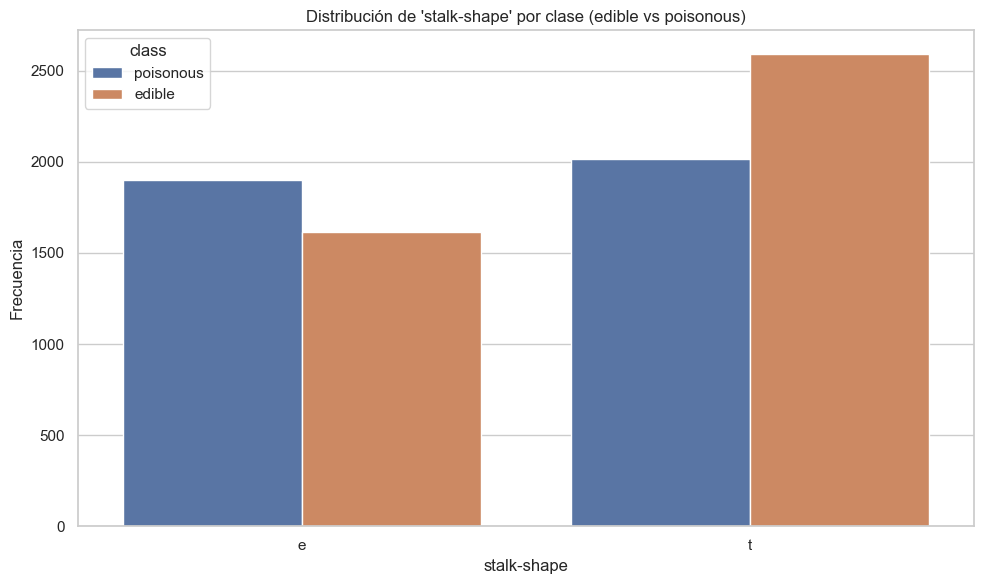

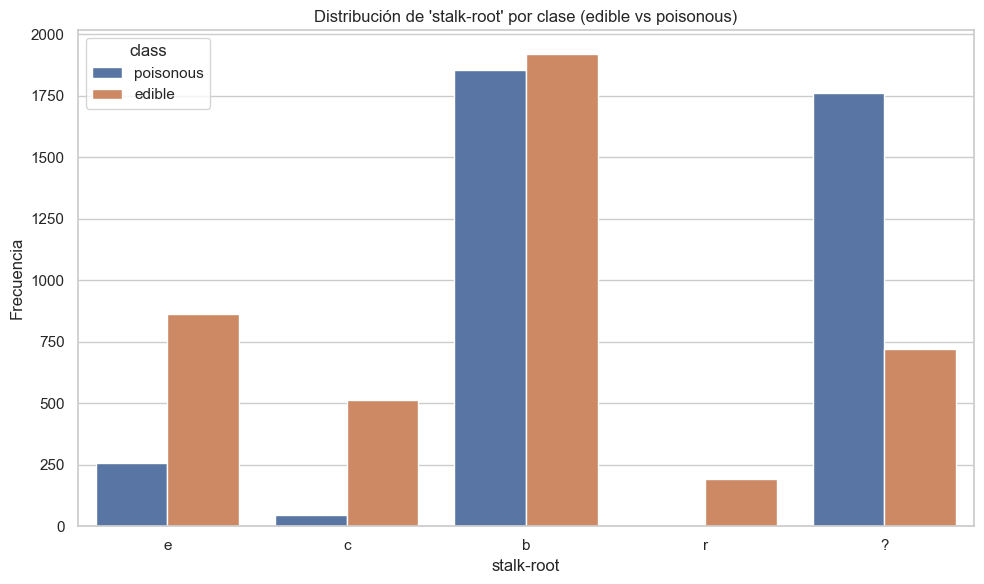

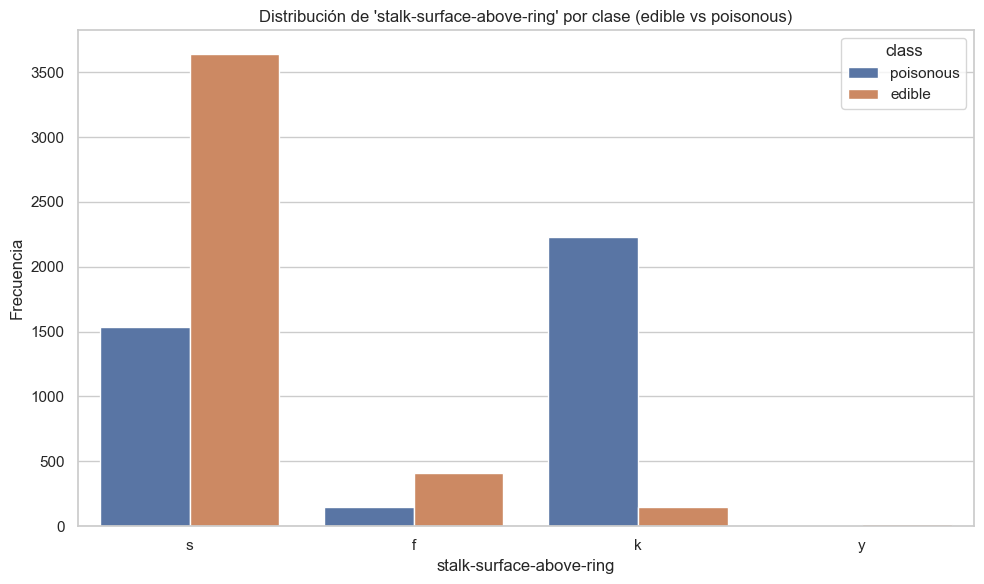

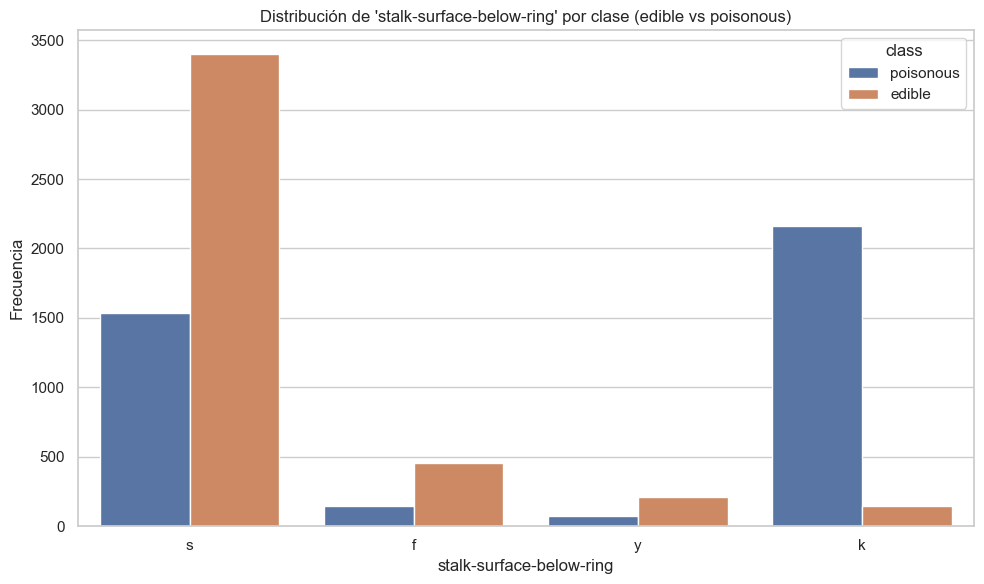

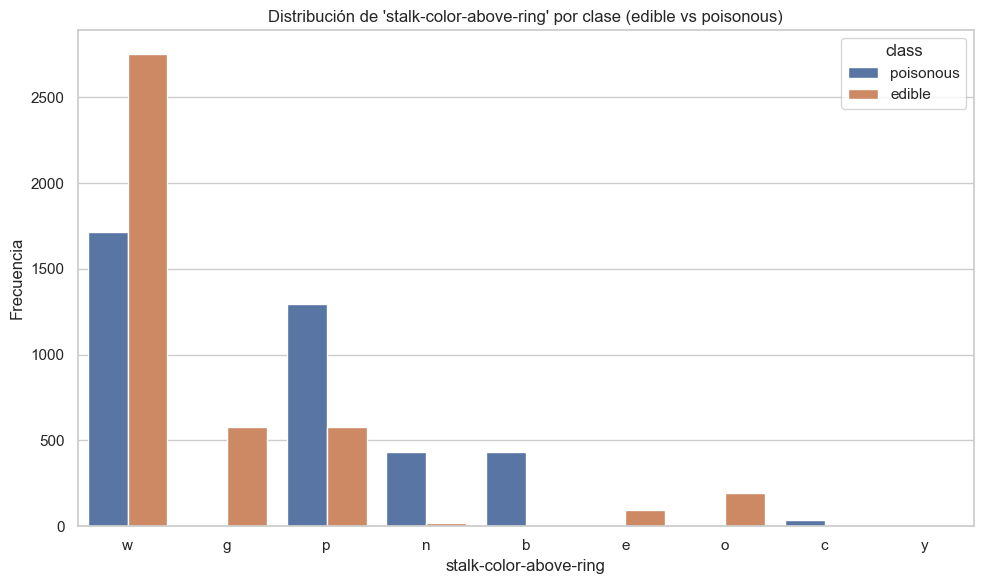

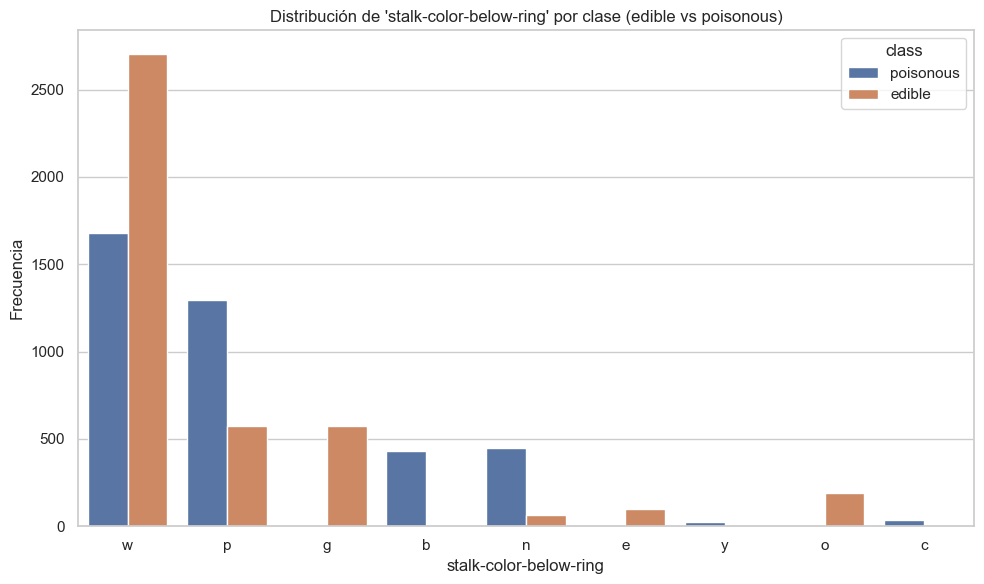

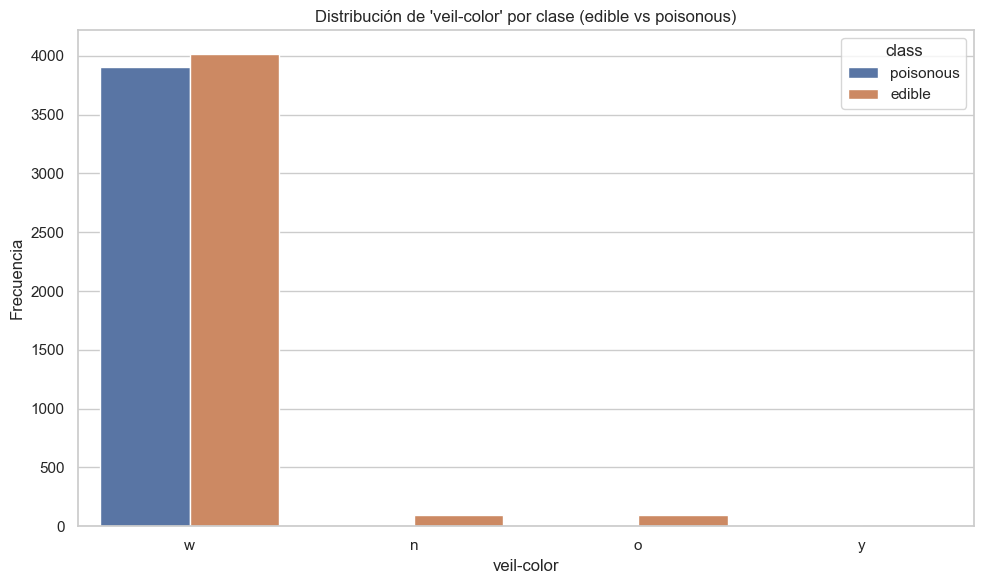

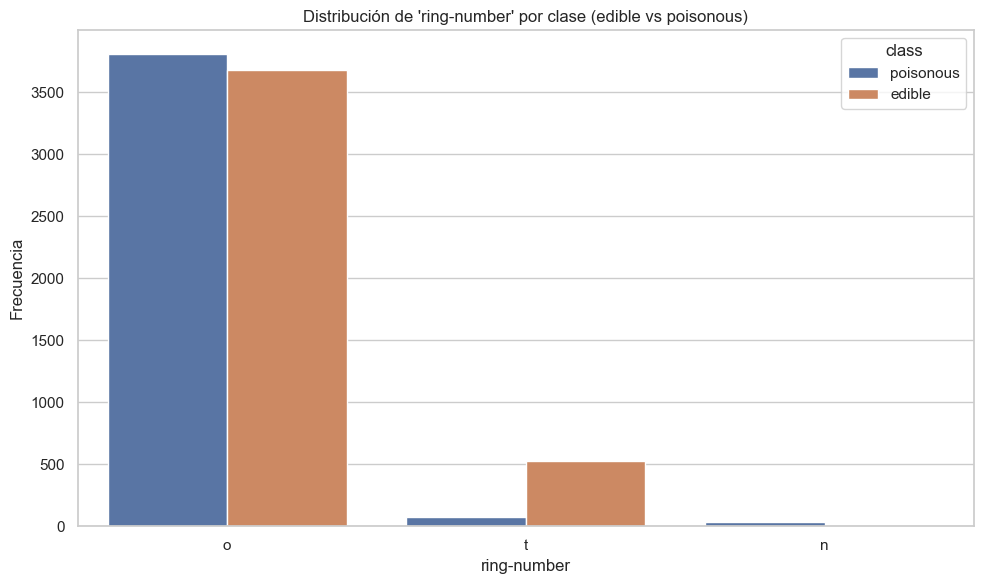

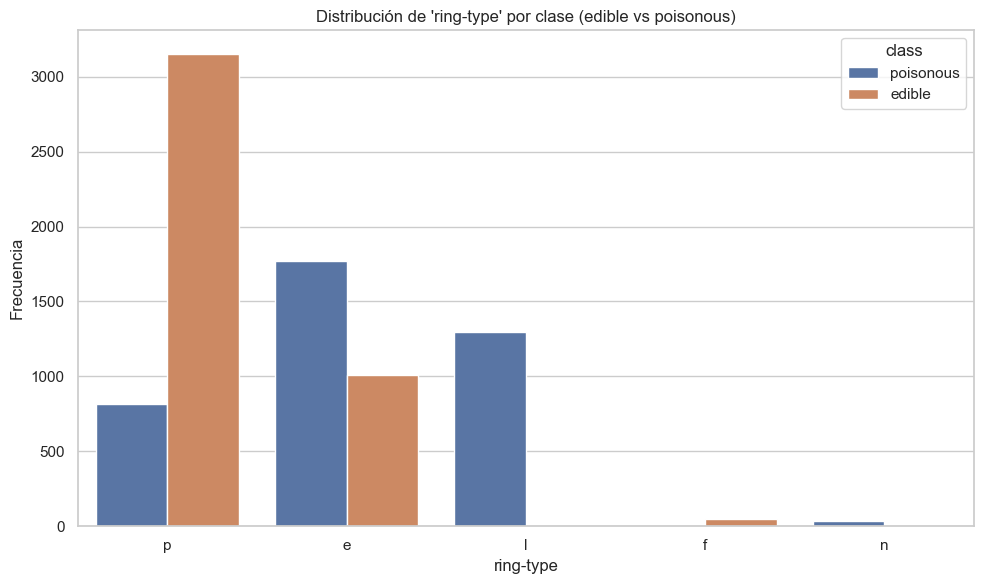

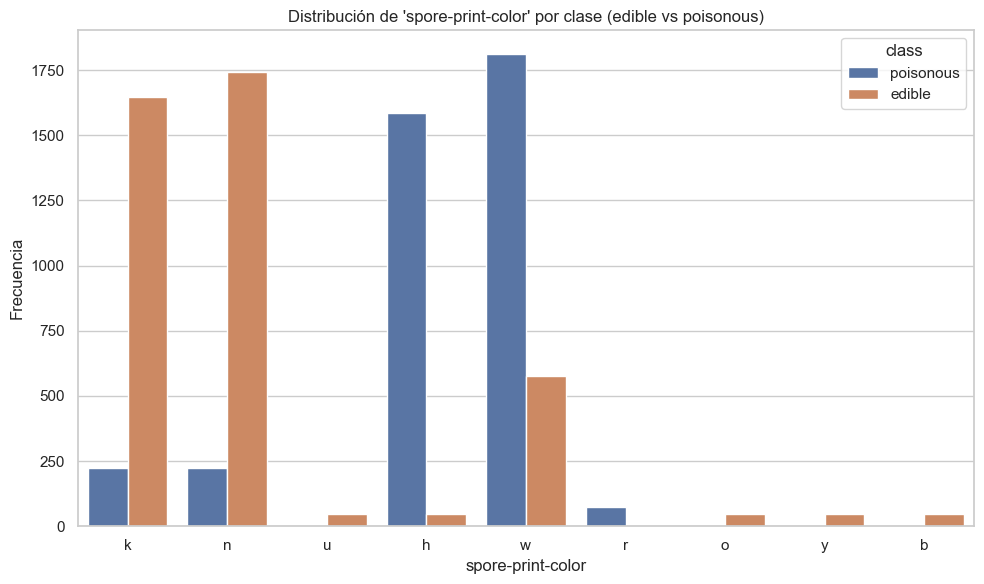

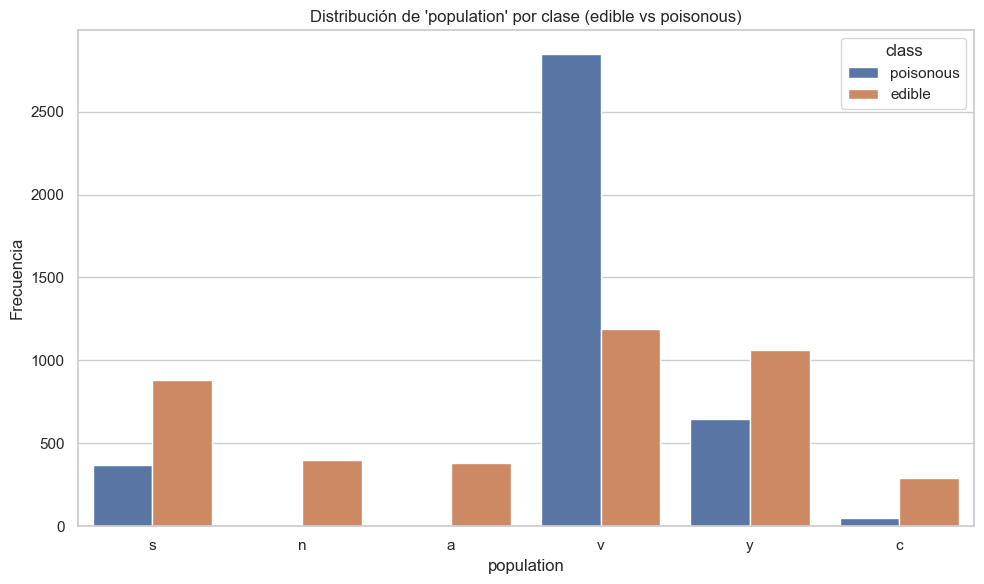

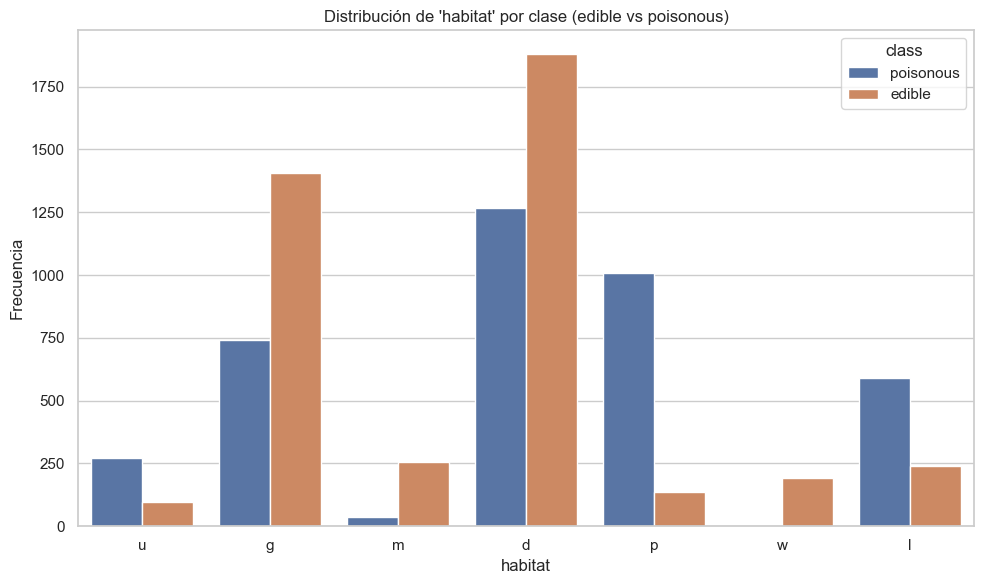

In [47]:
categorical_columns = [
    'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat'
]

for col in categorical_columns:
    plot_category_distribution(df_mushrooms, col)


In [42]:
def analyze_variable(df, column):
    print("="*80)
    print(f"VARIABLE: {column}")
    print("="*80)
    
    # Frecuencias absolutas
    print("\n📌 Frecuencia absoluta:")
    print(df[column].value_counts())
    
    # Frecuencias relativas
    print("\n📌 Frecuencia relativa (%):")
    print((df[column].value_counts(normalize=True) * 100).round(2))
    
    # Tabla cruzada con la clase
    print("\n📌 Distribución por clase (tabla cruzada):")
    print(pd.crosstab(df[column], df["class"]))
    
    # Tabla cruzada en porcentaje
    print("\n📌 Distribución por clase (%):")
    print((pd.crosstab(df[column], df["class"], normalize="index") * 100).round(2))

    print("\n\n")

# Lista de columnas categóricas del dataset
categorical_columns = [
    'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat'
]

# Ejecutar análisis para todas las variables
for col in categorical_columns:
    analyze_variable(df_mushrooms, col)


VARIABLE: cap-shape

📌 Frecuencia absoluta:
cap-shape
x    3656
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64

📌 Frecuencia relativa (%):
cap-shape
x    45.00
f    38.80
k    10.19
b     5.56
s     0.39
c     0.05
Name: proportion, dtype: float64

📌 Distribución por clase (tabla cruzada):
class         e     p
cap-shape            
b           404    48
c             0     4
f          1596  1556
k           228   600
s            32     0
x          1948  1708

📌 Distribución por clase (%):
class           e       p
cap-shape                
b           89.38   10.62
c            0.00  100.00
f           50.63   49.37
k           27.54   72.46
s          100.00    0.00
x           53.28   46.72



VARIABLE: cap-surface

📌 Frecuencia absoluta:
cap-surface
y    3244
s    2556
f    2320
g       4
Name: count, dtype: int64

📌 Frecuencia relativa (%):
cap-surface
y    39.93
s    31.46
f    28.56
g     0.05
Name: proportion, dtype: float64

📌 Distribución por c

Hay olores, colores de branquias, colores de esporas y patrones del tallo que aparecen al 100% en una sola clase.

Algunas variables están fuertemente asociadas a ser venenoso (p), otras a ser comestible (e).

1. Cap-shape (forma del sombrero)

La forma “c” aparece exclusivamente en hongos venenosos.

La forma “s” aparece exclusivamente en hongos comestibles.

La forma “k” se asocia mayormente a hongos venenosos (~72%).

Las formas “f” y “x” se distribuyen de manera equilibrada entre ambas clases.


2. Cap-surface (superficie del sombrero)

“g” aparece únicamente en hongos venenosos, aunque es muy poco frecuente.

“f” se asocia más a hongos comestibles (~67%).

3. Cap-color (color del sombrero)

Colores “r” y “u” aparecen exclusivamente en hongos comestibles.

“b”, “p” y “y” se relacionan más con hongos venenosos (60–70%).

4. Bruises (moretones)

“t” (con moretones) → 82% comestibles.

“f” (sin moretones) → 69% venenosos.

5. Odor (olor)

Esta es una de las variables más fuertes:

Olores almond (a) y anise (l) → 100% comestibles.

Olores creosote (c), foul (f), musty (m), pungent (p), fishy (y) y spicy (s) → 100% venenosos.

Olor none (n) → 96.6% comestibles.

6. Gill-attachment (unión de las láminas)

“a” se asocia principalmente a hongos comestibles (~91%).

“f” aparece en ambas clases casi por igual.

7. Gill-spacing (espaciado de las láminas)

“w” (crowded) → 91% comestibles.

“c” (close) → 56% venenosos.

8. Gill-size (tamaño de las láminas)

“n” → 88% venenosos.

“b” → 70% comestibles.

9. Gill-color (color de las láminas)

Categorías 100% venenosas:
b (buff), r (greenish-red)

Categorías 100% comestibles:
e (red), o (orange)

Otras asociaciones:
h (chocolate) y g (gray) son mayormente venenosos.
k, n, w, u aparecen más en comestibles.

11. Stalk-root (raíz del tallo)

“r” → 100% comestibles.

“c” y “e” → fuertes tendencias hacia comestibles.

“?” → 71% venenosos.

18. Ring-type

Categorías informativas:

l y n → 100% venenosas

f → 100% comestible

p → 79% comestible

e → 64% venenoso

19. Spore-print-color (color de impresión de esporas)

Categorías 100% comestibles:
b, o, u, y

Categorías mayormente venenosas:

h → 97% venenoso

w → 75% venenoso

r → 100% venenoso

20. Population (densidad de aparición)

a y n → 100% comestibles

v → 70% venenoso

s → 70% comestible

y → 62% comestible

21. Habitat (hábitat)

w (waste) → 100% comestible

m (meadows) → 88% comestible

p (paths) → 88% venenoso

u (urban) → 74% venenoso

l (leaves) → 71% venenoso


# Limpieza de datos

In [52]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

como no hay valores nulos y todas son categoricas, toca hacer one hot encode con variables con mas de 2 categorias
eliminar una de las categorias para evitar multicolinealidad
eliminar columnas multicolineales

In [48]:
# Separar variable objetivo
y = df_mushrooms["class"]
X = df_mushrooms.drop("class", axis=1)

# 2. One-Hot Encoding con drop_first
X_encoded = pd.get_dummies(X, drop_first=True)

y_encoded = pd.get_dummies(y, drop_first=True)

print("Shape después del one-hot:", X_encoded.shape)

Shape después del one-hot: (8124, 95)


In [49]:
y_encoded.head()

,p
0,True
1,False
2,False
3,True
4,False


In [50]:
X_encoded.head()

,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,cap-color_e,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,False,False,False,False,True,False,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False
1,False,False,False,False,True,False,True,False,False,False,...,True,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,True,False,False,False
3,False,False,False,False,True,False,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
4,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [53]:
# 3. Calcular VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X_encoded.columns
vif_data["VIF"] = [variance_inflation_factor(X_encoded.values, i) 
                   for i in range(X_encoded.shape[1])]

print(vif_data.sort_values("VIF", ascending=False).head(20))

                       feature           VIF
51    stalk-color-above-ring_c  2.961920e+12
59    stalk-color-below-ring_c  1.659090e+12
69                veil-color_y  1.504962e+12
58    stalk-color-above-ring_y  1.058052e+12
21                      odor_m  1.001690e+12
74                 ring-type_n  7.367250e+11
34                gill-color_o  5.221262e+11
72                 ring-type_f  4.949011e+11
39                gill-color_y  4.748128e+11
55    stalk-color-above-ring_o  1.268780e+11
94                   habitat_w  8.934207e+10
24                      odor_s  8.922083e+10
80         spore-print-color_r  7.261938e+10
47  stalk-surface-above-ring_y  5.703611e+10
63    stalk-color-below-ring_o  5.384440e+10
29                gill-color_e  4.915198e+10
18                      odor_c  3.079248e+10
73                 ring-type_l  2.588201e+10
36                gill-color_r  2.029750e+10
25                      odor_y  1.831215e+10


In [54]:
# 4. Eliminar variables con VIF > 10
cols_to_drop = vif_data[vif_data["VIF"] > 10]["feature"].tolist()

X_reduced = X_encoded.drop(columns=cols_to_drop)

print("Shape final sin multicolinealidad:", X_reduced.shape)

Shape final sin multicolinealidad: (8124, 39)


In [55]:
X_reduced.head()

,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,cap-color_p,...,spore-print-color_u,spore-print-color_y,population_c,population_n,population_s,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u
0,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,True
1,False,False,False,False,True,False,True,False,False,False,...,False,False,False,True,False,True,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,True,False,False
3,False,False,False,False,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
4,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


# modelo 1: Logit y probit

## Describir el modelo seleccionado y sus características.

## Entrenar el modelo

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3, random_state=42, stratify=y)

In [61]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=20)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)

In [62]:
# Hiperparámetros
C_values = [0.01, 0.1, 1, 10, 100]
penalties = ['l1', 'l2']
max_iters = [100, 500, 1000]
class_weights = [None, 'balanced']     # nuevo
k_values = [10, 15, 20, 25, 30]        # para SelectKBest

solver_map = {'l1': 'saga', 'l2': 'lbfgs'}

results = []

for k in k_values:
    # SelectKBest para este k
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_sel = selector.fit_transform(X_train, y_train)
    X_test_sel = selector.transform(X_test)

    for penalty in penalties:
        for C in C_values:
            for max_iter in max_iters:
                for cw in class_weights:

                    log_reg = LogisticRegression(
                        penalty=penalty,
                        C=C,
                        solver=solver_map[penalty],
                        max_iter=max_iter,
                        class_weight=cw,
                        n_jobs=-1
                    )

                    log_reg.fit(X_train_sel, y_train)
                    y_pred = log_reg.predict(X_test_sel)
                    y_prob = log_reg.predict_proba(X_test_sel)[:, 1]

                    auc = roc_auc_score(y_test, y_prob)
                    acc = accuracy_score(y_test, y_pred)
                    cm = confusion_matrix(y_test, y_pred)

                    results.append({
                        'k': k,
                        'penalty': penalty,
                        'C': C,
                        'max_iter': max_iter,
                        'class_weight': cw,
                        'accuracy': acc,
                        'auc': auc,
                        'confusion_matrix': cm
                    })


# Convertir a DataFrame y ordenar por AUC
results_df = pd.DataFrame(results).sort_values(by='accuracy', ascending=False)
print(results_df)


/Users/sophiaaristizabal/Documents/GitHub/taller3_ml/mi_entorno/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sophiaaristizabal/Documents/GitHub/taller3_ml/mi_entorno/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sophiaaristizabal/Documents/GitHub/taller3_ml/mi_entorno/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sophiaaristizabal/Documents/GitHub/taller3_ml/mi_entorno/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sophiaaristizabal/Documents/GitHub/taller3_ml/mi_entorno/lib/python3.14/site-pack

      k penalty       C  max_iter class_weight  accuracy       auc  \
299  30      l2  100.00      1000     balanced  0.917966  0.962210   
295  30      l2  100.00       100     balanced  0.917966  0.962210   
267  30      l1  100.00       500     balanced  0.917966  0.962241   
269  30      l1  100.00      1000     balanced  0.917966  0.962241   
297  30      l2  100.00       500     balanced  0.917966  0.962210   
..   ..     ...     ...       ...          ...       ...       ...   
185  25      l1    0.01      1000     balanced  0.821575  0.888834   
65   15      l1    0.01      1000     balanced  0.821575  0.879540   
64   15      l1    0.01      1000         None  0.821575  0.879540   
62   15      l1    0.01       500         None  0.821575  0.879540   
0    10      l1    0.01       100         None  0.821575  0.873064   

              confusion_matrix  
299  [[1199, 64], [136, 1039]]  
295  [[1199, 64], [136, 1039]]  
267  [[1199, 64], [136, 1039]]  
269  [[1199, 64], [136, 103

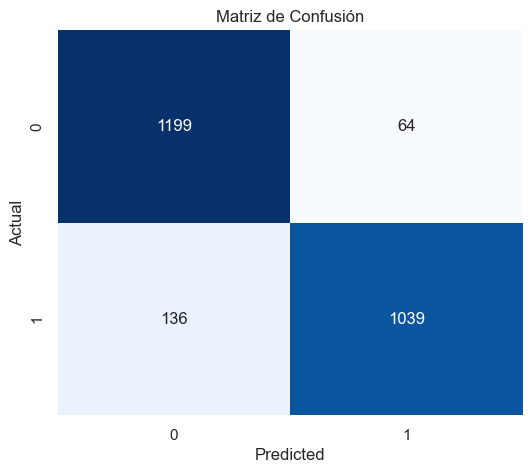

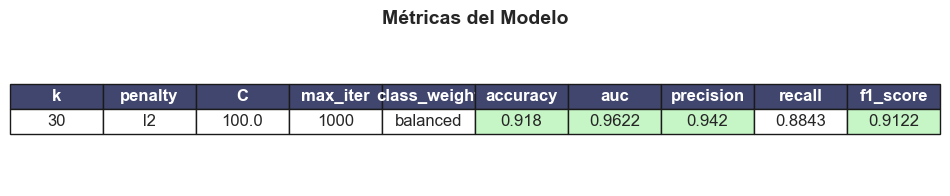

In [64]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# -----------------------------
# Matriz de confusión
cm = np.array([[1199, 64],
               [136, 1039]])

# Graficar matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión')
plt.show()

# -----------------------------
# Métricas
metrics_data = {
    'k': [30],
    'penalty': ['l2'],
    'C': [100.0],
    'max_iter': [1000],
    'class_weight': ['balanced'],
    'accuracy': [0.917966],
    'auc': [0.962210]
}

df_metrics = pd.DataFrame(metrics_data)

# Calcular precision, recall, f1 a partir de la matriz de confusión
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

df_metrics['precision'] = precision
df_metrics['recall'] = recall
df_metrics['f1_score'] = f1

# -----------------------------
# Crear una tabla bonita con matplotlib
fig, ax = plt.subplots(figsize=(10,2))  # Ajusta tamaño

ax.axis('tight')
ax.axis('off')
table_data = df_metrics.round(4)  # Redondear números a 4 decimales

# Crear tabla con color y estilo
tabla = ax.table(cellText=table_data.values,
                 colLabels=table_data.columns,
                 cellLoc='center',
                 loc='center')

tabla.auto_set_font_size(False)
tabla.set_fontsize(12)
tabla.scale(1.2, 1.5)  # Escala la tabla

# Color de cabecera
for (i, j), cell in tabla.get_celld().items():
    if i == 0:  # fila de cabecera
        cell.set_facecolor('#40466e')
        cell.set_text_props(weight='bold', color='w')
    else:
        # Colorear métricas por valor (solo ejemplos)
        if j in [5,6,7,8,9]:  # columnas de métricas
            value = float(cell.get_text().get_text())
            if value > 0.9:
                cell.set_facecolor('#c6f5c6')  # verde claro
            elif value < 0.7:
                cell.set_facecolor('#f5c6c6')  # rojo claro

plt.title("Métricas del Modelo", fontsize=14, weight='bold')
plt.show()



## modelo 2: Random forest

In [67]:
from sklearn.model_selection import RandomizedSearchCV

In [69]:
# ==============================
# Selección de variables (todas las variables numéricas)
# ==============================


selector = SelectKBest(score_func=f_classif, k=X_train.shape[1])
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)

# ==============================
# 3️⃣ Definir espacio de búsqueda de hiperparámetros
# ==============================
param_dist = {
    'n_estimators': [200, 300, 400, 500, 600],   # número de árboles
    'max_depth': [None, 10, 20, 30],            # profundidad máxima
    'min_samples_split': [2, 5, 10],            # mínimo samples para dividir
    'min_samples_leaf': [1, 2, 4],              # mínimo samples por hoja
    'max_features': ['sqrt', 'log2', None],     # máximo features a considerar
    'bootstrap': [True, False]                  # usar bootstrap o no
}

# ==============================
# 4️⃣ Configurar Random Forest
# ==============================
rf = RandomForestClassifier(
    class_weight='balanced', 
    random_state=42
)

# ==============================
# 5️⃣ RandomizedSearchCV
# ==============================
rand_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=100,           # probar 100 combinaciones aleatorias
    scoring='roc_auc',    # optimizar por AUC
    cv=3,                 # validación cruzada 3 folds
    n_jobs=-1,            # usar todos los cores disponibles
    verbose=2,
    random_state=42
)

# Entrenar Random Forest con búsqueda aleatoria
rand_search.fit(X_train_sel, y_train)

# ==============================
#  Evaluar el mejor modelo
# ==============================
best_rf = rand_search.best_estimator_
y_pred = best_rf.predict(X_test_sel)
y_prob = best_rf.predict_proba(X_test_sel)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print("Mejores hiperparámetros encontrados:")
print(rand_search.best_params_)
print(f"Accuracy: {acc:.4f}")
print(f"AUC: {auc:.4f}")
print("Matriz de confusión:")
print(cm)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=   0.7s
[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=   0.7s
[CV] END bootstrap=True, max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   1.2s
[CV] END bootstrap=True, max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   1.3s
[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=   0.5s
[CV] END bootstrap=True, max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   1.3s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=

*resultados en tablas lindas*

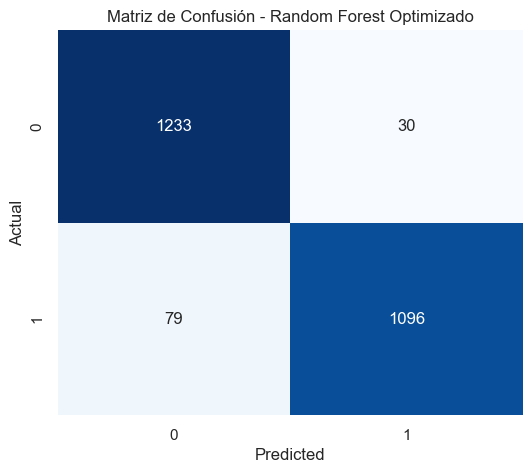

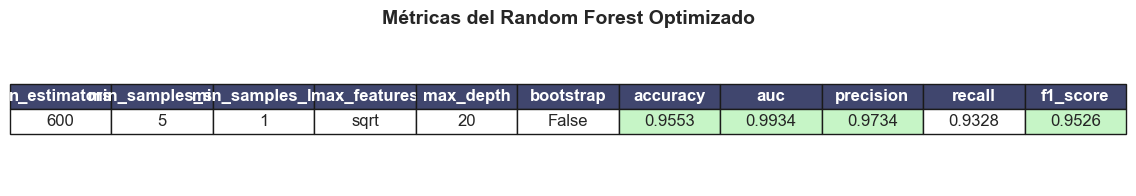

In [70]:
# -----------------------------
# Matriz de confusión del nuevo Random Forest
cm = np.array([[1233, 30],
               [79, 1096]])

# Graficar matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión - Random Forest Optimizado')
plt.show()

# -----------------------------
# Métricas
accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)
auc = 0.9934  # AUC obtenido del modelo

metrics_data = {
    'n_estimators': [600],
    'min_samples_split': [5],
    'min_samples_leaf': [1],
    'max_features': ['sqrt'],
    'max_depth': [20],
    'bootstrap': [False],
    'accuracy': [accuracy],
    'auc': [auc],
    'precision': [precision],
    'recall': [recall],
    'f1_score': [f1]
}

df_metrics = pd.DataFrame(metrics_data)

# -----------------------------
# Crear tabla bonita con matplotlib
fig, ax = plt.subplots(figsize=(12,2))  # Ajusta tamaño

ax.axis('tight')
ax.axis('off')
table_data = df_metrics.round(4)  # Redondear números a 4 decimales

# Crear tabla con color y estilo
tabla = ax.table(cellText=table_data.values,
                 colLabels=table_data.columns,
                 cellLoc='center',
                 loc='center')

tabla.auto_set_font_size(False)
tabla.set_fontsize(12)
tabla.scale(1.2, 1.5)  # Escala la tabla

# Color de cabecera
for (i, j), cell in tabla.get_celld().items():
    if i == 0:  # fila de cabecera
        cell.set_facecolor('#40466e')
        cell.set_text_props(weight='bold', color='w')
    else:
        # Colorear métricas por valor
        if j in [6,7,8,9,10]:  # columnas de métricas
            value = float(cell.get_text().get_text())
            if value > 0.95:
                cell.set_facecolor('#c6f5c6')  # verde claro
            elif value < 0.7:
                cell.set_facecolor('#f5c6c6')  # rojo claro

plt.title("Métricas del Random Forest Optimizado", fontsize=14, weight='bold')
plt.show()

## Interpretacion de resultados

# Parte B Aprendizaje No Supervisado

# En tendimiento del dataset

¿Qué información presenta el dataset?, describir las principales características del dataset, y a su vez identificar la variable sobre la cual se desea hacer el agrupamiento.

# Descripción del Dataset de Tarjetas de Crédito

Este dataset contiene información de aproximadamente 9000 titulares activos de tarjetas de crédito durante los últimos 6 meses.  
El objetivo del análisis es desarrollar una **segmentación de clientes** que permita definir estrategias de marketing personalizadas.  

El dataset está a nivel **cliente individual** y contiene **18 variables**, detalladas a continuación:

| Variable | Tipo | Descripción / Categorías |
|----------|------|-------------------------|
| **CUST_ID** | Categórica | Identificador único del titular de la tarjeta de crédito. |
| **BALANCE** | Numérica | Balance restante en la cuenta para realizar compras. |
| **BALANCE_FREQUENCY** | Numérica (0-1) | Frecuencia de actualización del balance (1 = muy frecuente, 0 = nunca). |
| **PURCHASES** | Numérica | Monto total de compras realizadas desde la cuenta. |
| **ONEOFF_PURCHASES** | Numérica | Máximo monto de compra realizado en una sola transacción. |
| **INSTALLMENTS_PURCHASES** | Numérica | Monto de compras realizadas en cuotas o pagos parciales. |
| **CASH_ADVANCE** | Numérica | Efectivo retirado anticipadamente por el usuario. |
| **PURCHASES_FREQUENCY** | Numérica (0-1) | Frecuencia con la que se realizan compras (1 = muy frecuente, 0 = nunca). |
| **ONEOFF_PURCHASES_FREQUENCY** | Numérica (0-1) | Frecuencia de compras en una sola transacción. |
| **PURCHASES_INSTALLMENTS_FREQUENCY** | Numérica (0-1) | Frecuencia de compras en cuotas. |
| **CASH_ADVANCE_FREQUENCY** | Numérica (0-1) | Frecuencia de retiro de efectivo anticipado. |
| **CASH_ADVANCE_TRX** | Numérica | Número de transacciones de retiro de efectivo anticipado. |
| **PURCHASES_TRX** | Numérica | Número total de transacciones de compra realizadas. |
| **CREDIT_LIMIT** | Numérica | Límite de crédito disponible en la tarjeta. |
| **PAYMENTS** | Numérica | Total de pagos realizados por el usuario. |
| **MINIMUM_PAYMENTS** | Numérica | Monto mínimo de pagos realizados. |
| **PRC_FULL_PAYMENT** | Numérica | Porcentaje de pago total realizado respecto al monto adeudado. |
| **TENURE** | Numérica | Tiempo de servicio de la tarjeta de crédito en meses. |

---

## Información general del dataset

- **Tipo de datos:** Predominantemente numéricos continuos, con un identificador categórico (`CUST_ID`).  
- **Dimensiones:** ~9000 filas × 18 columnas.  
- **Nivel de detalle:** Cliente individual, centrado en comportamiento financiero y hábitos de compra.  
- **Objetivo del análisis:** Comprender los patrones de uso y segmentar clientes para estrategias de marketing.  

---

## Variable para el agrupamiento

Para la **segmentación de clientes**, se ha seleccionado **una sola variable de referencia**:

- **BALANCE**: Balance restante en la cuenta para realizar compras.

> Esta variable permite agrupar clientes según su capacidad de gasto y manejo de su balance disponible. Los clusters obtenidos reflejarán segmentos de clientes con comportamiento financiero similar, facilitando la toma de decisiones para estrategias de marketing personalizadas.

El agrupamiento se realiza usando todas las variables numéricas de comportamiento financiero, pero la variable principal que guía la segmentación es BALANCE, ya que indica la capacidad de gasto de cada cliente.

# Realice un análisis gráfico y estadístico que permita ver la distribución y ver algunas correlaciones.

In [85]:
df_credit = pd.read_csv('credit_card.csv')

In [86]:
df_credit.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [87]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [88]:
df_credit.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


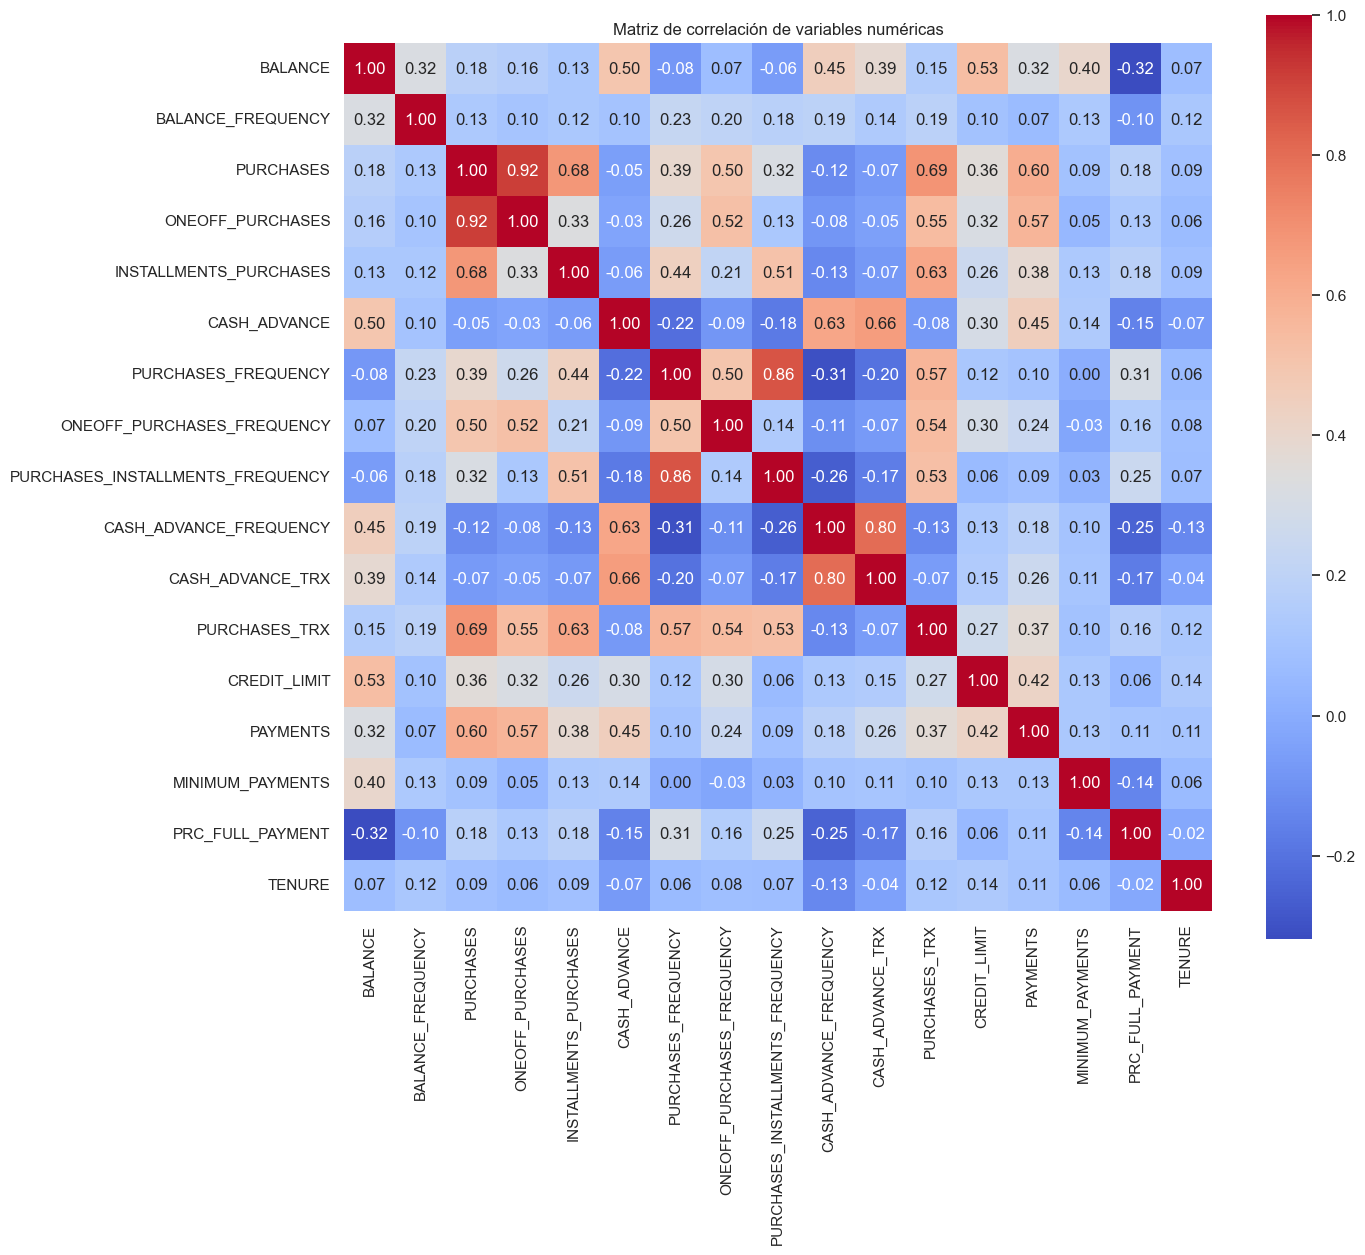

In [89]:
# -------------------------------
# Calcular matriz de correlación (solo variables numéricas)
# -------------------------------
corr_matrix = df_credit.corr(numeric_only=True)

# -------------------------------
# Graficar heatmap de correlación
# -------------------------------
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f", square=True, cbar=True)
plt.title("Matriz de correlación de variables numéricas")
plt.show()

# Limpieza de datos

quitar datos muy multicolineales ONEOFF_PURCHASES_FREQUENCY y PURCHASES_INSTALLMENTS_FREQUENCY

In [91]:
#quitar datos muy multicolineales ONEOFF_PURCHASES_FREQUENCY y PURCHASES_INSTALLMENTS_FREQUENCY
df_credit= df_credit.loc[:, ~np.isin(df_credit.columns, ['ONEOFF_PURCHASES_FREQUENCY_RANGE', 'PURCHASES_INSTALLMENTS_FREQUENCY_RANGE'])]

In [93]:
df_credit.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [94]:
df_credit.loc[(df_credit['MINIMUM_PAYMENTS'].isnull()==True),'MINIMUM_PAYMENTS']=df_credit['MINIMUM_PAYMENTS'].mean()
df_credit.loc[(df_credit['CREDIT_LIMIT'].isnull()==True),'CREDIT_LIMIT']=df_credit['CREDIT_LIMIT'].mean()

quitar outliers

In [95]:
columns=['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
        'PAYMENTS', 'MINIMUM_PAYMENTS']

for c in columns:
    
    Range=c+'_RANGE'
    df_credit[Range]=0        
    df_credit.loc[((df_credit[c]>0)&(df_credit[c]<=500)),Range]=1
    df_credit.loc[((df_credit[c]>500)&(df_credit[c]<=1000)),Range]=2
    df_credit.loc[((df_credit[c]>1000)&(df_credit[c]<=3000)),Range]=3
    df_credit.loc[((df_credit[c]>3000)&(df_credit[c]<=5000)),Range]=4
    df_credit.loc[((df_credit[c]>5000)&(df_credit[c]<=10000)),Range]=5
    df_credit.loc[((df_credit[c]>10000)),Range]=6

In [96]:
columns=['BALANCE_FREQUENCY', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 
         'CASH_ADVANCE_FREQUENCY', 'PRC_FULL_PAYMENT']

for c in columns:
    
    Range=c+'_RANGE'
    df_credit[Range]=0
    df_credit.loc[((df_credit[c]>0)&(df_credit[c]<=0.1)),Range]=1
    df_credit.loc[((df_credit[c]>0.1)&(df_credit[c]<=0.2)),Range]=2
    df_credit.loc[((df_credit[c]>0.2)&(df_credit[c]<=0.3)),Range]=3
    df_credit.loc[((df_credit[c]>0.3)&(df_credit[c]<=0.4)),Range]=4
    df_credit.loc[((df_credit[c]>0.4)&(df_credit[c]<=0.5)),Range]=5
    df_credit.loc[((df_credit[c]>0.5)&(df_credit[c]<=0.6)),Range]=6
    df_credit.loc[((df_credit[c]>0.6)&(df_credit[c]<=0.7)),Range]=7
    df_credit.loc[((df_credit[c]>0.7)&(df_credit[c]<=0.8)),Range]=8
    df_credit.loc[((df_credit[c]>0.8)&(df_credit[c]<=0.9)),Range]=9
    df_credit.loc[((df_credit[c]>0.9)&(df_credit[c]<=1.0)),Range]=10

In [97]:
columns=['PURCHASES_TRX', 'CASH_ADVANCE_TRX']  

for c in columns:
    
    Range=c+'_RANGE'
    df_credit[Range]=0
    df_credit.loc[((df_credit[c]>0)&(df_credit[c]<=5)),Range]=1
    df_credit.loc[((df_credit[c]>5)&(df_credit[c]<=10)),Range]=2
    df_credit.loc[((df_credit[c]>10)&(df_credit[c]<=15)),Range]=3
    df_credit.loc[((df_credit[c]>15)&(df_credit[c]<=20)),Range]=4
    df_credit.loc[((df_credit[c]>20)&(df_credit[c]<=30)),Range]=5
    df_credit.loc[((df_credit[c]>30)&(df_credit[c]<=50)),Range]=6
    df_credit.loc[((df_credit[c]>50)&(df_credit[c]<=100)),Range]=7
    df_credit.loc[((df_credit[c]>100)),Range]=8

In [98]:
df_credit.drop(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY',  'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT' ], axis=1, inplace=True)

X= np.asarray(df_credit)

normalizacion

In [99]:
scale = StandardScaler()
X = scale.fit_transform(X)
X.shape

(8950, 17)

# Construcción del modelo

In [100]:
from sklearn.cluster import KMeans

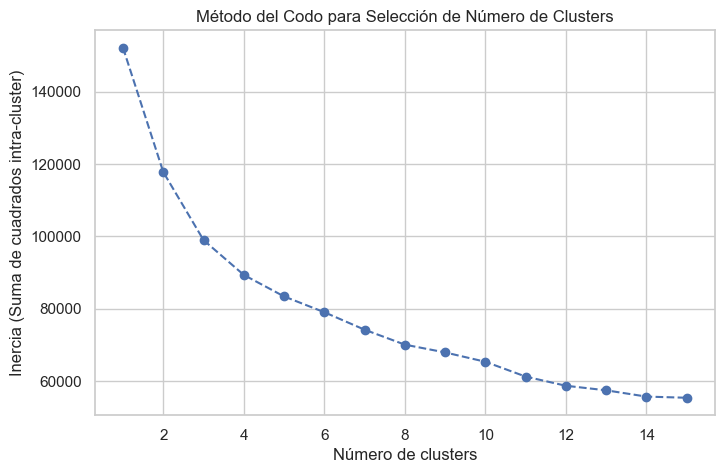

In [101]:
# -------------------------------
# Metodología para seleccionar el número de clusters
# -------------------------------

# Número máximo de clusters a probar
max_clusters = 15
inertia_values = []

# Evaluar inercia para k=1 a max_clusters
for k in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, init='k-means++', max_iter=300)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(8,5))
plt.plot(range(1, max_clusters + 1), inertia_values, marker='o', linestyle='--')
plt.xlabel("Número de clusters")
plt.ylabel("Inercia (Suma de cuadrados intra-cluster)")
plt.title("Método del Codo para Selección de Número de Clusters")
plt.show()

In [114]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [115]:
# Hiperparámetros a probar
init_list = ['k-means++', 'random']
max_iter_list = [100, 200, 300, 500]

results = []

for init_method in init_list:
    for max_iter_val in max_iter_list:
        kmeans = KMeans(
            n_clusters=4,
            init=init_method,
            max_iter=max_iter_val,
            random_state=42
        )
        kmeans.fit(X)
        labels = kmeans.labels_

        # Métricas de evaluación
        sil_score = silhouette_score(X, labels)
        cal_score = calinski_harabasz_score(X, labels)
        db_score = davies_bouldin_score(X, labels)

        results.append({
            'init': init_method,
            'max_iter': max_iter_val,
            'silhouette_score': sil_score,
            'calinski_harabasz': cal_score,
            'davies_bouldin': db_score
        })

# Convertir a DataFrame y ordenar por Silhouette Score
df_results = pd.DataFrame(results).sort_values(by='silhouette_score', ascending=False)
df_results

,init,max_iter,silhouette_score,calinski_harabasz,davies_bouldin
0,k-means++,100,0.174830,2095.864766,1.677443
1,k-means++,200,0.174830,2095.864766,1.677443
2,k-means++,300,0.174830,2095.864766,1.677443
3,k-means++,500,0.174830,2095.864766,1.677443
4,random,100,0.173491,2095.937027,1.683243
5,random,200,0.173491,2095.937027,1.683243
6,random,300,0.173491,2095.937027,1.683243
7,random,500,0.173491,2095.937027,1.683243


In [119]:
# -------------------------------
# Entrenamiento del modelo K-Means con el número de clusters seleccionado
# -------------------------------

# del gráfico del codo seleccionamos 4 clusters
k_selected = 4

kmeans_final = KMeans(
    n_clusters=k_selected,
    init='k-means++',   # Inicialización de centroides
    max_iter=100,       # Número máximo de iteraciones
    random_state=42
)

# Entrenar el modelo
kmeans_final.fit(X)

# Asignar etiquetas de cluster
labels = kmeans_final.labels_

# Agregar etiquetas al dataset original
clusters = pd.concat([df_credit.reset_index(drop=True), pd.DataFrame({'cluster': labels})], axis=1)
clusters.head()

,TENURE,BALANCE_RANGE,PURCHASES_RANGE,ONEOFF_PURCHASES_RANGE,INSTALLMENTS_PURCHASES_RANGE,CASH_ADVANCE_RANGE,CREDIT_LIMIT_RANGE,PAYMENTS_RANGE,MINIMUM_PAYMENTS_RANGE,BALANCE_FREQUENCY_RANGE,PURCHASES_FREQUENCY_RANGE,ONEOFF_PURCHASES_FREQUENCY_RANGE,PURCHASES_INSTALLMENTS_FREQUENCY_RANGE,CASH_ADVANCE_FREQUENCY_RANGE,PRC_FULL_PAYMENT_RANGE,PURCHASES_TRX_RANGE,CASH_ADVANCE_TRX_RANGE,cluster
0,12,1,1,0,1,0,2,1,1,9,2,0,1,0,0,1,0,1
1,12,4,0,0,0,5,5,4,3,10,0,0,0,3,3,0,1,3
2,12,3,2,2,0,0,5,2,2,10,10,10,0,0,0,3,0,0
3,12,3,3,3,0,1,5,0,2,7,1,1,0,1,0,1,1,1
4,12,2,1,1,0,0,3,2,1,10,1,1,0,0,0,1,0,1


In [120]:
# ===============================
# Resumen de parámetros utilizados
# ===============================
print("Parámetros del modelo K-Means:")
print(f"Inicialización de centroides: {kmeans_final.init}")
print(f"Número de iteraciones máximo: {kmeans_final.max_iter}")
print(f"Número de clusters seleccionado: {k_selected}")

Parámetros del modelo K-Means:
Inicialización de centroides: k-means++
Número de iteraciones máximo: 100
Número de clusters seleccionado: 4


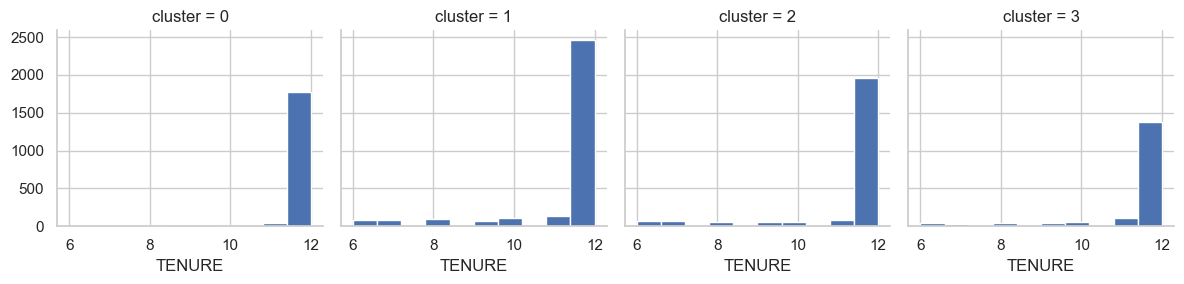

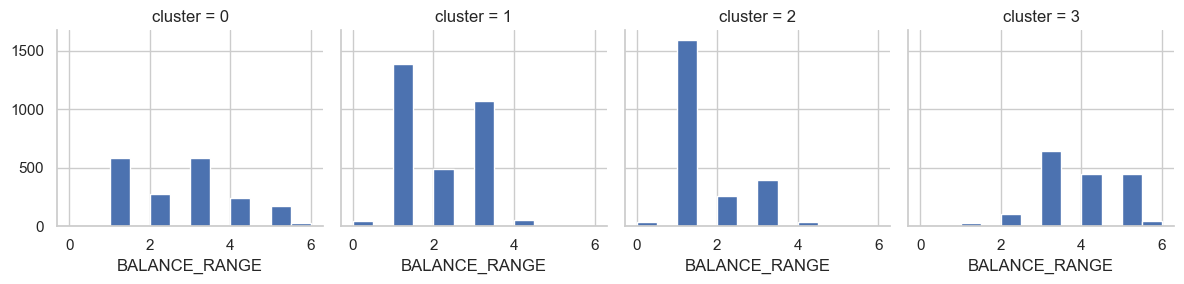

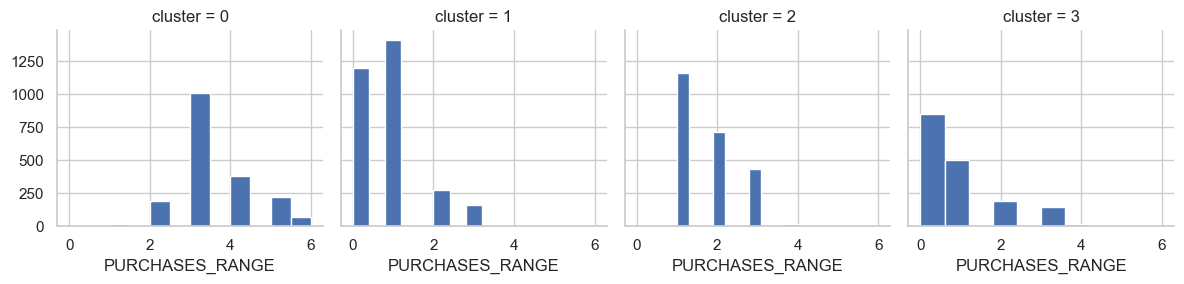

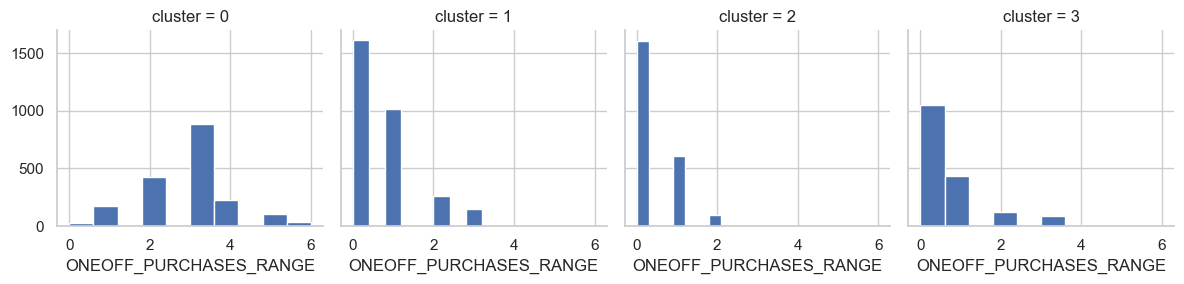

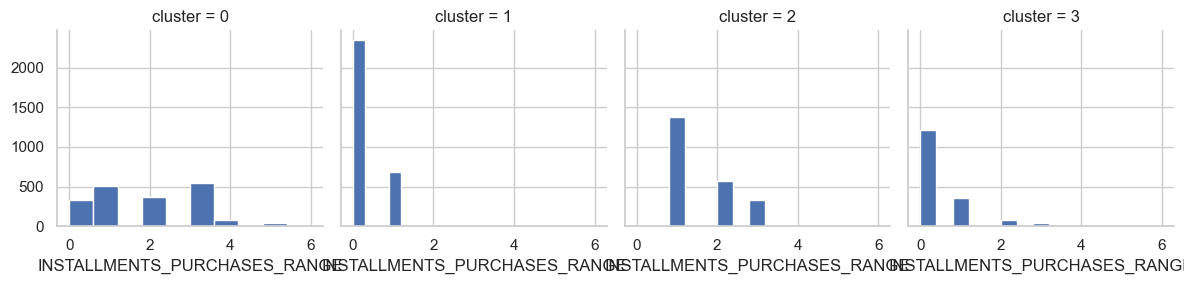

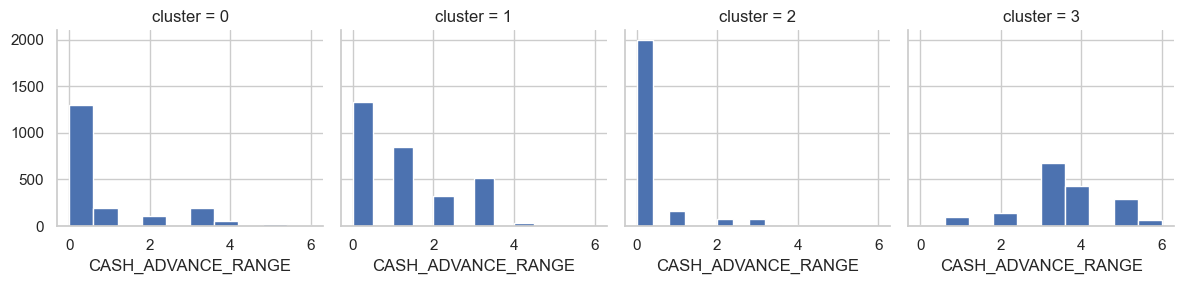

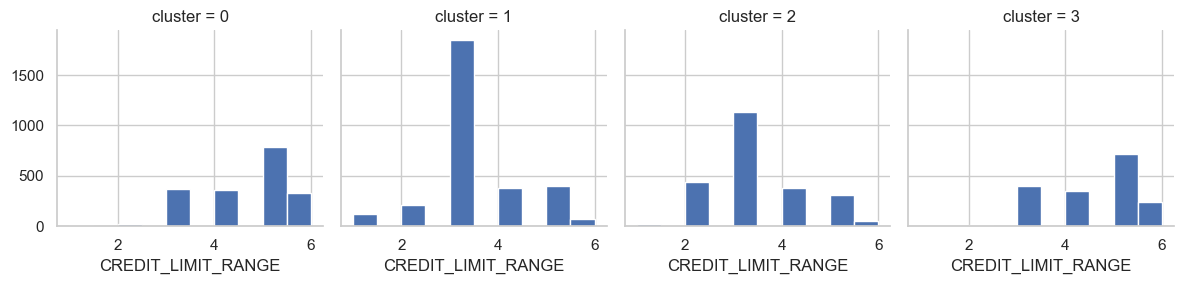

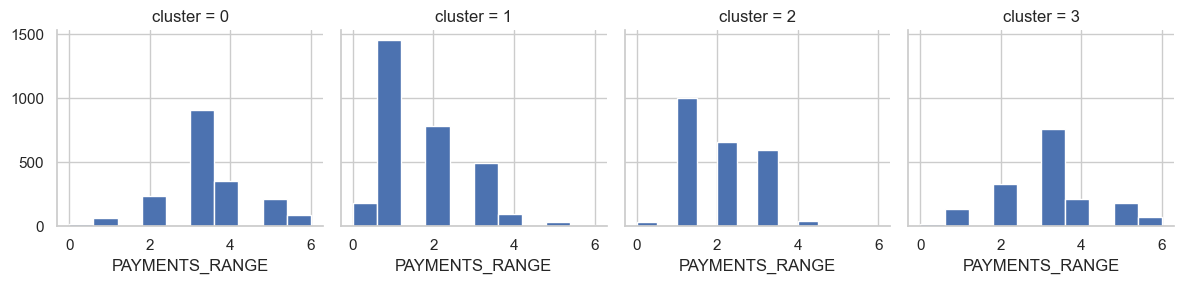

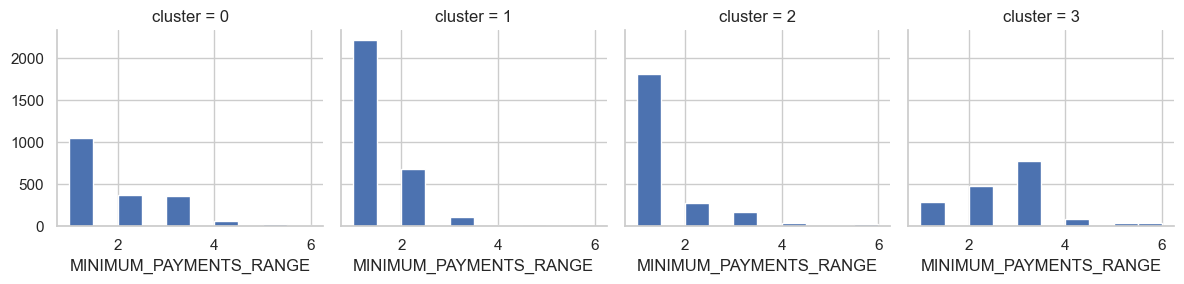

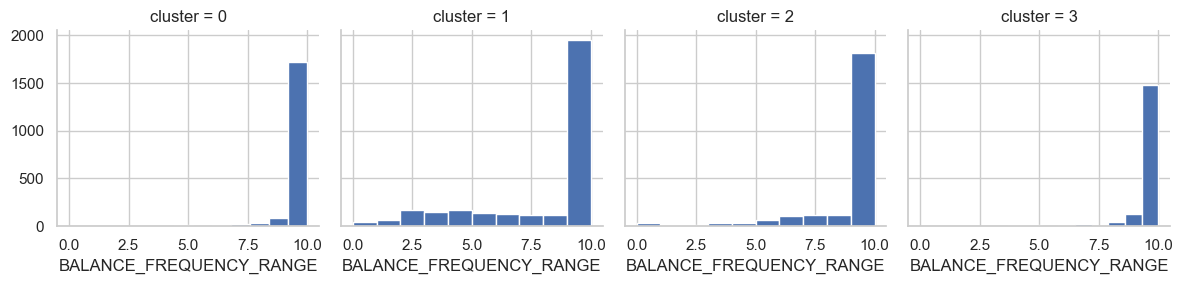

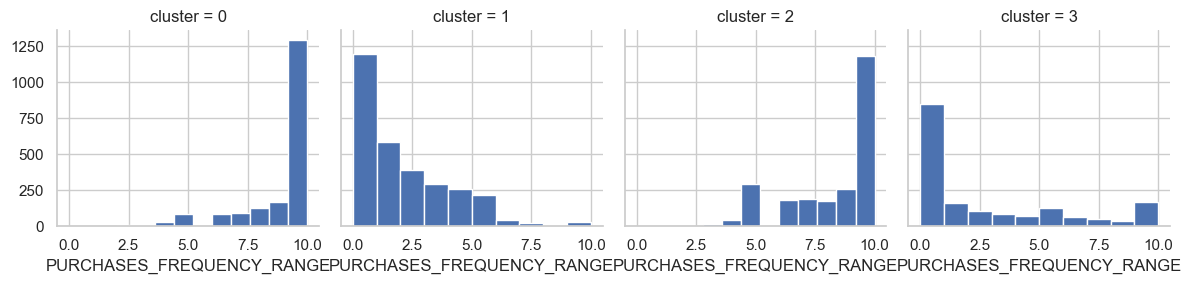

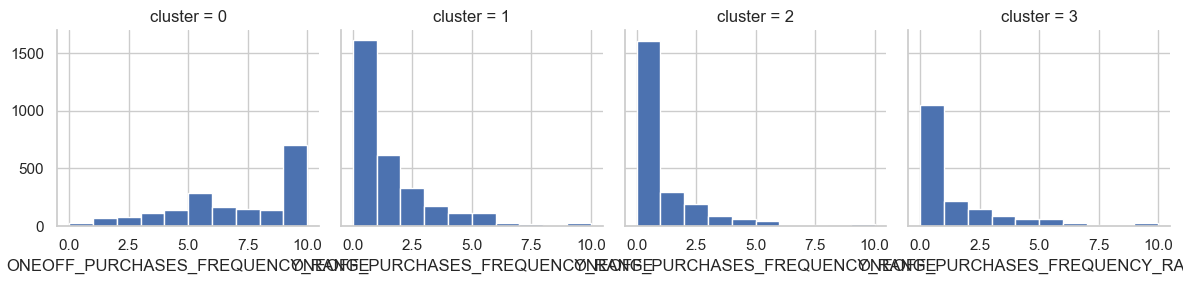

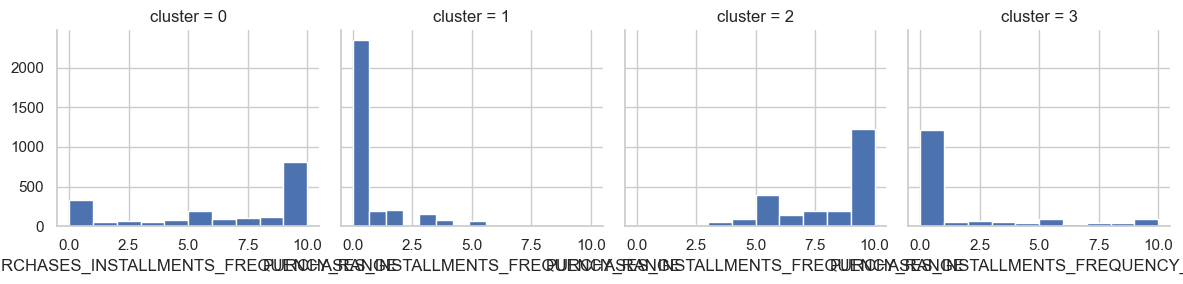

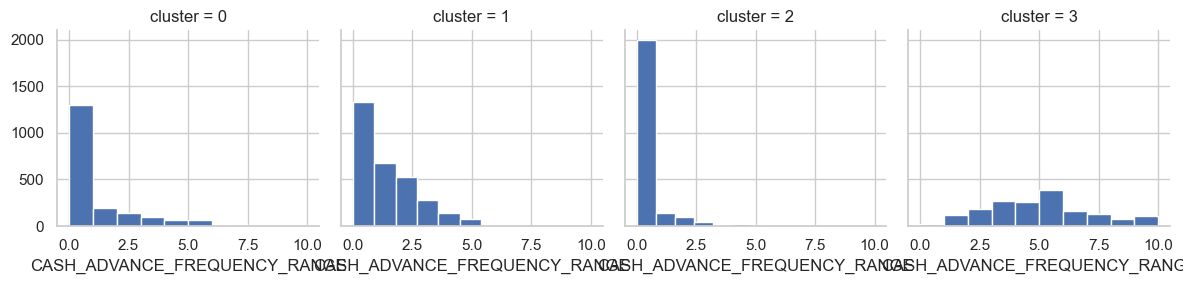

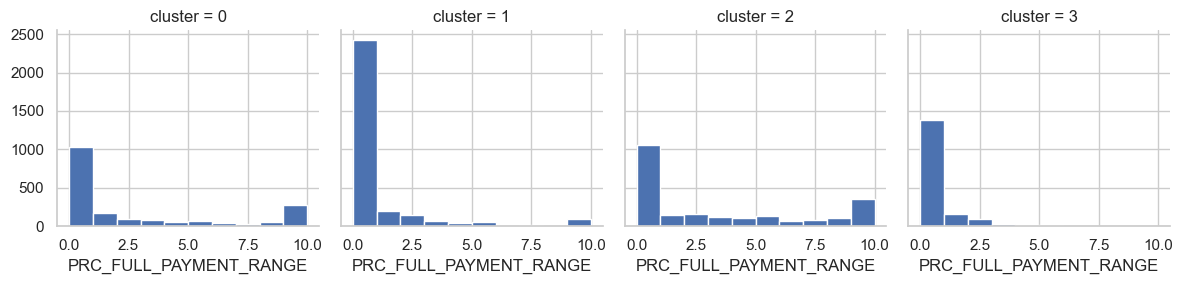

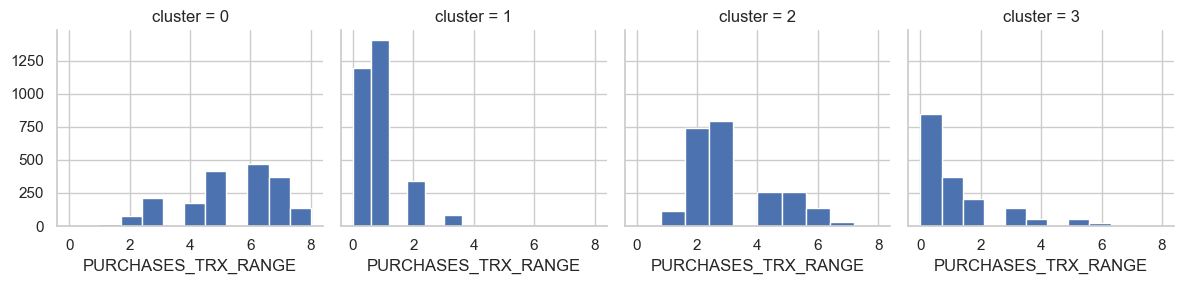

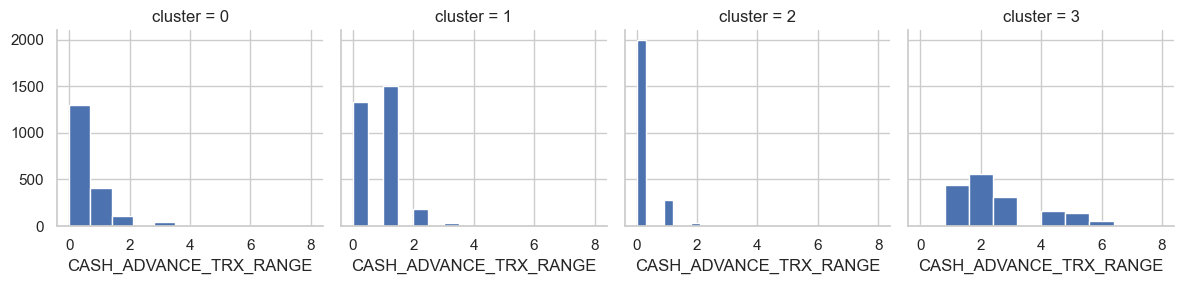

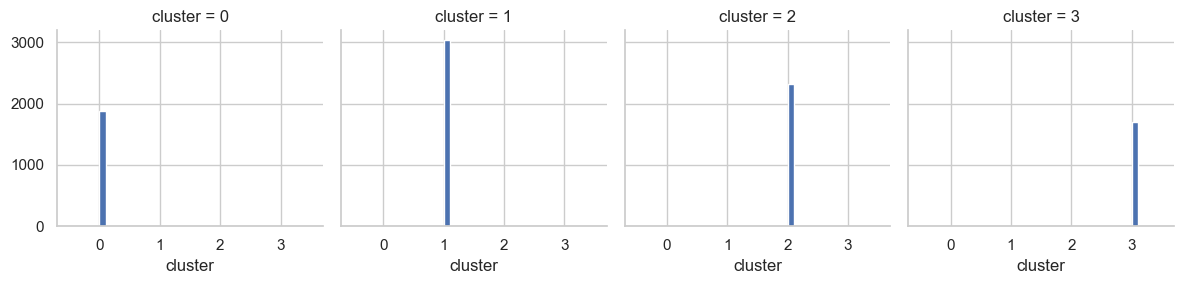

In [121]:
for c in clusters:
    grid= sns.FacetGrid(clusters, col='cluster')
    grid.map(plt.hist, c)

In [122]:
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

In [123]:
dist = 1 - cosine_similarity(X)
pca = PCA(2)
pca.fit(dist)
X_PCA = pca.transform(dist)

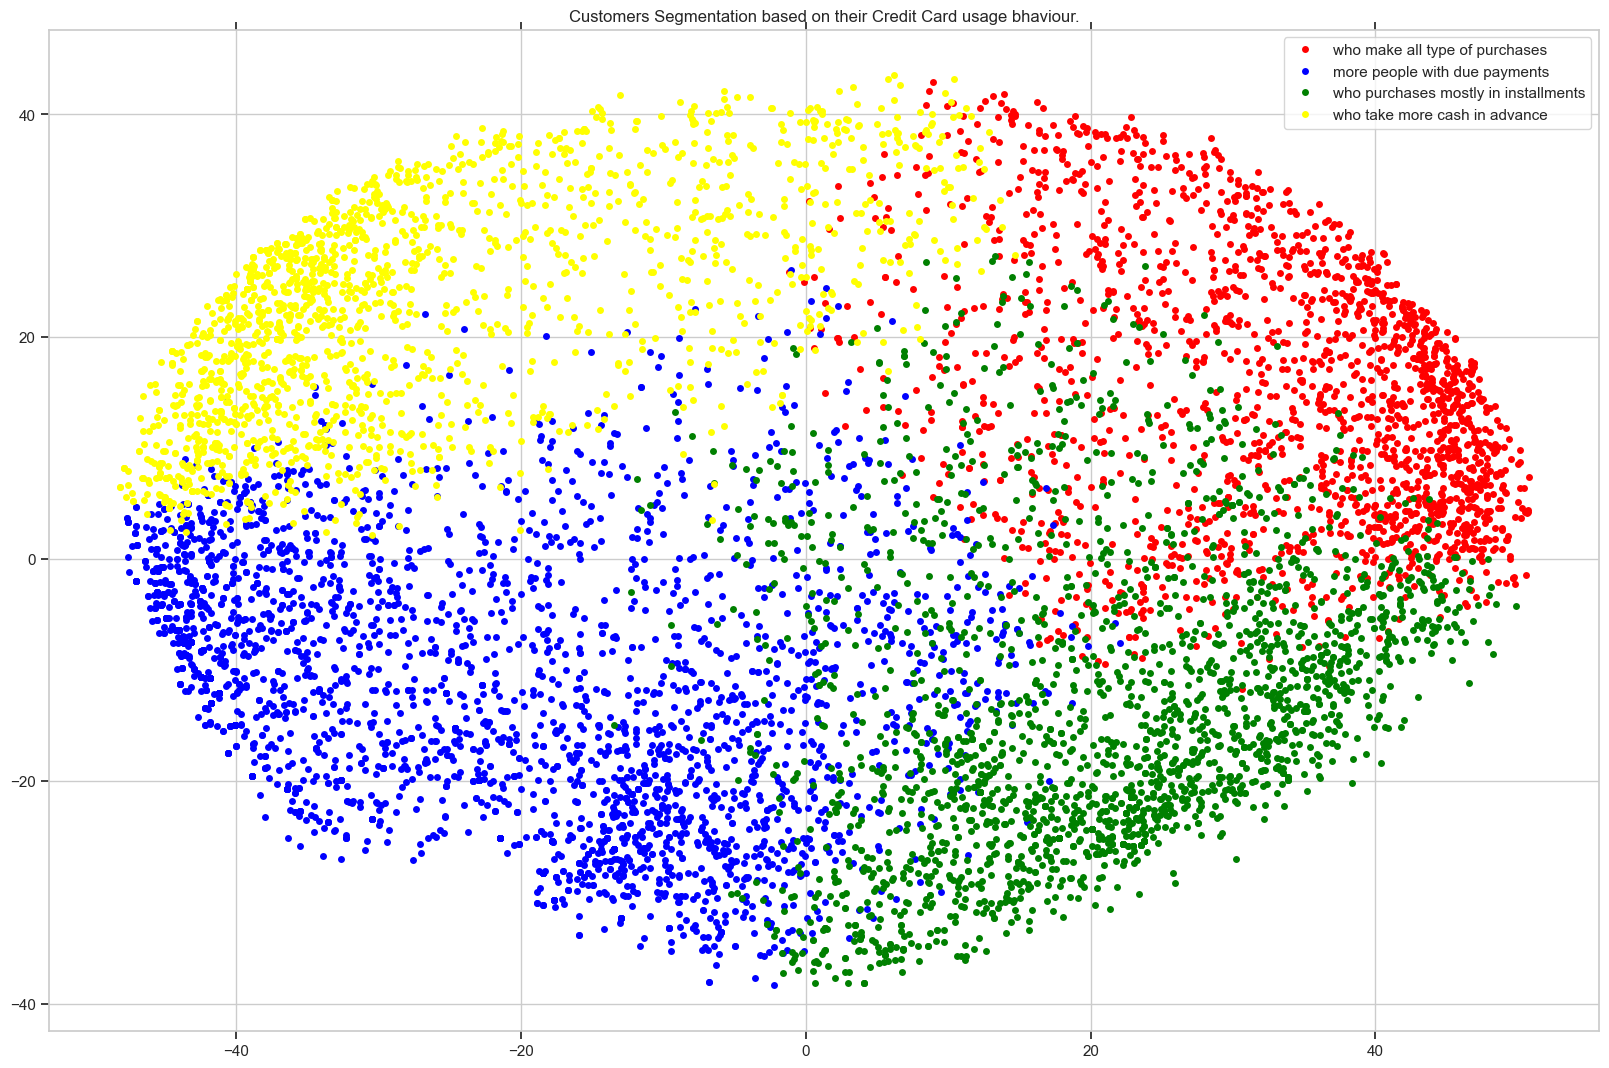

In [124]:
x, y = X_PCA[:, 0], X_PCA[:, 1]

colors = {0: 'red',
          1: 'blue',
          2: 'green', 
          3: 'yellow', 
          4: 'orange',  
          5:'purple'}

names = {0: 'who make all type of purchases', 
         1: 'more people with due payments', 
         2: 'who purchases mostly in installments', 
         3: 'who take more cash in advance', 
         4: 'who make expensive purchases',
         5:'who don\'t spend much money'}
  
df = pd.DataFrame({'x': x, 'y':y, 'label':labels}) 
groups = df.groupby('label')

fig, ax = plt.subplots(figsize=(20, 13)) 

for name, group in groups:
    ax.plot(group.x, group.y, marker='o', linestyle='', ms=5,
            color=colors[name],label=names[name], mec='none')
    ax.set_aspect('auto')
    ax.tick_params(axis='x',which='both',bottom='off',top='off',labelbottom='off')
    ax.tick_params(axis= 'y',which='both',left='off',top='off',labelleft='off')
    
ax.legend()
ax.set_title("Customers Segmentation based on their Credit Card usage bhaviour.")
plt.show()

# Métricas de evaluación

In [126]:
from sklearn.metrics import silhouette_samples, silhouette_score

Silhouette Score promedio: 0.1748


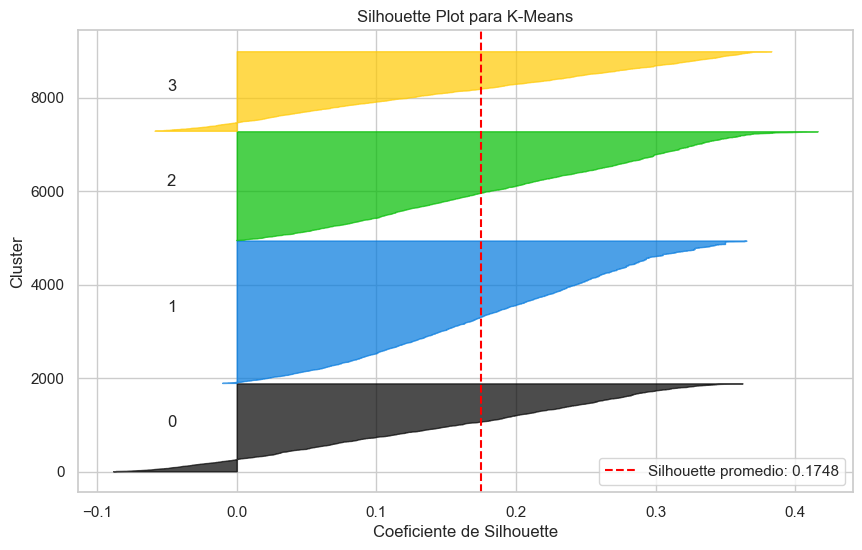

In [130]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import KMeans
import numpy as np

# Supongamos que tu mejor KMeans ya está entrenado:
n_clusters = 4
kmeans_best = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=100, random_state=42)
labels = kmeans_best.fit_predict(X)

# Calcular coeficientes de Silhouette
silhouette_vals = silhouette_samples(X, labels)
silhouette_avg = silhouette_score(X, labels)
print(f"Silhouette Score promedio: {silhouette_avg:.4f}")

# -----------------------------
# Crear el gráfico de Silhouette
# -----------------------------
y_lower = 10
plt.figure(figsize=(10,6))

for i in range(n_clusters):
    # Valores de silhouette de los puntos en el cluster i
    ith_cluster_silhouette_values = silhouette_vals[labels == i]
    ith_cluster_silhouette_values.sort()
    
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    # CORRECTO: colormap de matplotlib
    color = cm.nipy_spectral(float(i) / n_clusters)
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    
    # Etiqueta del cluster
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    
    y_lower = y_upper + 10  # espacio entre clusters

plt.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"Silhouette promedio: {silhouette_avg:.4f}")
plt.xlabel("Coeficiente de Silhouette")
plt.ylabel("Cluster")
plt.title("Silhouette Plot para K-Means")
plt.legend()
plt.show()


 # Interpretación de resultados

Con base a los resultados obtenidos del modelo interpretar los resultados obtenidos

• Calidad de los resultados

• Interpretación de los clusters para el modelo

• ¿Tiene alguna interpretación desde el punto de vista del negocio?